# **Module 9 Project 2: Clustering + SVM: Can We Predict Purchases from Web Sites?**

**Author:** Nicolette Mtisi

The purpose of this project is to analyze and predict **online shopper purchasing behavior** using **clustering** and **Support Vector Machine (SVM)** models. Using the **Online Shoppers Purchasing Intention Dataset** from the UCI Machine Learning Repository, we aim to identify patterns among website visitors and predict whether a visitor will make a purchase (`Revenue`).

The notebook follows a clear sequence beginning with **data exploration** and **preparation**, followed by the application of **hierarchical** and **K-Means clustering** to uncover behavioral groupings. The clustering results are compared with actual purchase outcomes to evaluate alignment.

Finally, we develop and assess multiple **SVM models** using different feature sets and kernels to classify purchasing intentions. Model performance is compared using metrics such as **accuracy**, **precision**, **recall**, and **F1-score** to select the most effective predictive model.



# **1. Introduction**

The purpose of this assignment is to **analyze and predict online shopper purchasing behavior** using a combination of **clustering** and **Support Vector Machine (SVM)** techniques. The goal is to identify behavioral patterns among website visitors and build a predictive model that determines whether a visitor is likely to make a purchase.

The project involves two main phases: **Clustering**, to group similar user sessions based on browsing and engagement metrics, and **SVM modeling**, to classify purchasing outcomes based on these identified patterns.

The dataset used is the **Online Shoppers Purchasing Intention Dataset** from the **UCI Machine Learning Repository**, which includes various numerical and categorical attributes describing user sessions—such as the number of pages visited, time spent, month of visit, and purchase status (`Revenue`), the target variable indicating whether a transaction occurred.

The workflow for this project follows a structured, research-oriented sequence:

* **Data Loading**

  * Import the **Online Shoppers Purchasing Intention Dataset** from the UCI Machine Learning Repository.
  * Inspect the dataset to confirm structure, completeness, and variable types.

* **Pre-Clustering Exploratory Data Analysis (EDA)**

  * Explore key numerical and categorical features through summary statistics and visualizations.
  * Identify missing values, outliers, and scaling requirements to assess data readiness for clustering.

* **Data Preparation and Feature Engineering**

  * Encode categorical variables and standardize numerical attributes.
  * Apply transformations or feature engineering where necessary to improve model performance.

* **Clustering Modeling**

  * Perform **Hierarchical Clustering** and visualize the **Dendrogram** to explore data grouping patterns.
  * Implement **K-Means Clustering** and use **Elbow** and **Silhouette** plots to determine the optimal number of clusters.
  * Assign cluster labels and interpret group differences.

* **Post-Clustering Analysis**

  * Conduct EDA on cluster results to analyze behavioral differences between clusters (e.g., K=2).
  * Compare cluster-based labels (`Revenue`) with actual purchase outcomes (`V_Revenue`) to evaluate consistency.

* **SVM Modeling**

  * Select key features for supervised modeling and split the data into training and testing sets.
  * Build multiple **Support Vector Machine (SVM)** models using different kernel functions and hyperparameters.
  * Evaluate model performance using cross-validation.

* **Model Selection and Evaluation**

  * Compare SVM models based on **accuracy**, **precision**, **recall**, and **F1-score**.
  * Select the best-performing model and validate it on unseen data.

* **Comparison of Clustering + SVM Outputs with Actual Labels**

  * Evaluate how closely the predicted values align with the true purchase outcomes (`V_Revenue`).
  * Analyze similarities, differences, and overall model effectiveness.

* **Conclusions**

  * Summarize findings, highlight the most effective modeling approach, and discuss implications for predicting online purchasing behavior.



# **2. Data Loading**

In this section, the feature and label datasets are retrieved directly from GitHub using their raw CSV URLs. The data is then loaded into pandas DataFrames to verify successful import and ensure both files align in shape and structure.


In [ ]:
# Section 1 — Load main data (from GitHub)


# File paths
data_path   = 'https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/07-clustering-svm-online-shoppers/Project2_Data.csv'
labels_path = 'https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/07-clustering-svm-online-shoppers/Project2_Data_Labels.csv'

# Imports
import pandas as pd
import numpy as np

# Load datasets
df      = pd.read_csv(data_path)     # main dataframe
labels  = pd.read_csv(labels_path)   # labels kept separate

# Display basic info
print(" Dataset loaded successfully from GitHub!")
print(f"Shape (features): {df.shape}")
print(f"Shape (labels)  : {labels.shape}")

print("\n Preview of features:")
display(df.head())

print("\n Preview of labels:")
display(labels.head())


 Dataset loaded successfully from GitHub!
Shape (features): (12330, 17)
Shape (labels)  : (12330, 1)

 Preview of features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,8,222.000000,0.000000,0.028571,53.474571,0.0,May,1,1,1,2,New_Visitor,True
1,0,0.0,0,0.0,14,1037.500000,0.014286,0.047619,0.000000,0.0,Mar,2,2,4,2,Returning_Visitor,False
2,4,37.5,2,82.0,4,96.625000,0.000000,0.017500,0.000000,0.0,Nov,2,2,9,2,New_Visitor,False
3,4,115.7,0,0.0,16,655.383333,0.000000,0.012037,0.000000,0.0,Nov,1,1,2,3,Returning_Visitor,False
4,1,60.0,1,15.0,26,670.166667,0.000000,0.003846,0.000000,0.0,May,2,2,3,4,Returning_Visitor,False



 Preview of labels:


,Revenue
0,True
1,False
2,False
3,False
4,False


* The dataset was successfully imported from GitHub into two separate DataFrames — one containing features and another containing the target variable.
* The features dataset includes 12,330 records across 17 columns, while the label file contains 12,330 corresponding revenue outcomes, ensuring perfect alignment for supervised modeling.
* The feature columns capture user interaction details such as product engagement, session duration, and browsing behavior, along with categorical attributes like *Month*, *OperatingSystems*, and *VisitorType*.
* The target variable, **Revenue**, is Boolean (`True`/`False`), indicating whether a user completed a purchase during their session.
* This confirms that the dataset is cleanly structured and ready for exploratory data analysis (EDA) and subsequent modeling.


## **2.1 Initial Data Inspection**

This section inspects the loaded DataFrame’s structure, data types, and memory footprint, checks for missing values, and computes basic numeric summaries.

Together these checks confirm data integrity and highlight distributional issues to address in EDA and preprocessing.

In [ ]:
# General dataset info
print(" Dataset Information:")
df.info()

# Missing values check
print("\n Missing Values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found ")

# Descriptive statistics (numeric summary)
print("\n Basic Descriptive Statistics:")
display(df.describe().T)

 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


**Dataset info**  — 12,330 rows × 17 columns.

**Missing values** — No missing values found; the dataset is complete and ready for further analysis.

**Scale & dispersion** — Some numeric features (e.g., `ProductRelated_Duration` max ≈ 63,973; `PageValues` max ≈ 361.76) show very large maxima and high std devs, indicating right skew and outliers.

**Central tendency** — Many medians and 25% values are 0 (sparse interactions), so distributions are skewed and contain many low/zero sessions.

## **2.2 Variable Classification**

A crucial part of the exploratory phase is identifying the nature of each variable — whether it is **categorical** or **numerical** — since each requires distinct analytical and visualization techniques.

The following code segment automates this process by:

* **Step 1:** Using pandas’ `select_dtypes()` to classify variables based on their data types (`object`, `bool` for categorical and `int64`, `float64` for numerical).
* **Step 2:** Manually reclassifying certain variables (`OperatingSystems`, `Browser`, `Region`, `TrafficType`) that are stored as numbers but represent coded categories.
  This ensures that all variables are correctly grouped for later descriptive analysis and visualization.

In [ ]:
# Step 1 — Detect variable types by dtype
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Step 2 — Reclassify coded categorical numerics (per dataset documentation)
coded_cats = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

for c in coded_cats:
    if c in num_cols:
        num_cols.remove(c)
        cat_cols.append(c)

# Step 3 — Display results
print("\n Final Variable Classification:")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")



 Final Variable Classification:
Categorical Columns (7): ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Numerical Columns (10): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


**Findings:**

* The script successfully identified and categorized the dataset’s features into categorical and numerical groups.
* **Categorical variables (7):** Include features like *Month*, *VisitorType*, and *Weekend*, along with encoded categories such as *OperatingSystems*, *Browser*, *Region*, and *TrafficType*. These represent qualitative attributes that describe session type, user identity, and source characteristics—best analyzed using frequency distributions and proportion plots.
* **Numerical variables (10):** Consist of quantitative metrics such as *Administrative*, *Informational*, and *ProductRelated* counts, their corresponding durations, and performance indicators like *BounceRates*, *ExitRates*, *PageValues*, and *SpecialDay*. These are suitable for numerical summaries (mean, median, variance) and visual exploration through histograms and boxplots.

This classification lays a strong groundwork for subsequent EDA, enabling focused statistical and visual analyses tailored to each variable type.


# **3. Pre-Clustering Exploratory Data Analysis**

## **3.1 Univariate Analysis — Numeric Variables**

**Numeric Variables: Defining an Analysis Function**

To make our univariate analysis systematic and consistent across all numerical variables, we define a reusable function called **`plot_numeric_univariate()`**. This function ensures that every numeric feature is analyzed using the same structure of summary statistics and visual diagnostics — improving both efficiency and interpretability in our EDA process.

The function performs the following key actions:

1. **Summary Statistics** – Prints a transposed `.describe()` output for the selected variable, providing measures such as count, mean, standard deviation, minimum, quartiles, and maximum values.
2. **Histogram with KDE Curve** – Plots a histogram with an overlaid Kernel Density Estimate, helping identify the distribution shape (normal, right-skewed, or left-skewed) and detect patterns or peaks.
3. **Boxplot Visualization** – Creates a boxplot that highlights the median, quartiles, and potential outliers, offering an immediate visual sense of variability and spread.

This function uses **Seaborn** and **Matplotlib** for visualizations and ensures uniform aesthetics through the `whitegrid` style. Together, these components offer both statistical and visual insights for each numeric variable.


In [ ]:
# Section 3 — Univariate Analysis: Numeric

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

def plot_numeric_univariate(df, col):
    """Displays summary stats, histogram, and boxplot for one numeric variable."""
    print(f"\n Summary Statistics for '{col}'")
    display(pd.DataFrame(df[col].describe()).T)

    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    # Histogram with KDE
    sns.histplot(df[col], kde=True, bins=30, color="skyblue", ax=ax[0])
    ax[0].set_title(f"{col} — Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(x=df[col], color="lightcoral", ax=ax[1])
    ax[1].set_title(f"{col} — Boxplot")
    ax[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### **3.1.1 Administrative**

We will begin our univariate exploration with the **Administrative** variable, which represents the number of administrative pages visited by users during their sessions. Administrative pages often include account settings, help pages, or other non-product-specific content. Understanding the distribution of this variable is crucial for identifying user engagement patterns, optimizing website navigation, and tailoring user support strategies.

By analyzing the **Administrative** variable, we aim to answer the following key questions:
- What is the typical number of administrative pages visited by a user?
- What is the overall range of administrative page visits?
- Is the distribution symmetric, or is it skewed toward a particular group?
- Are there any unusual patterns or potential outliers in the data?




 Summary Statistics for 'Administrative'


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0


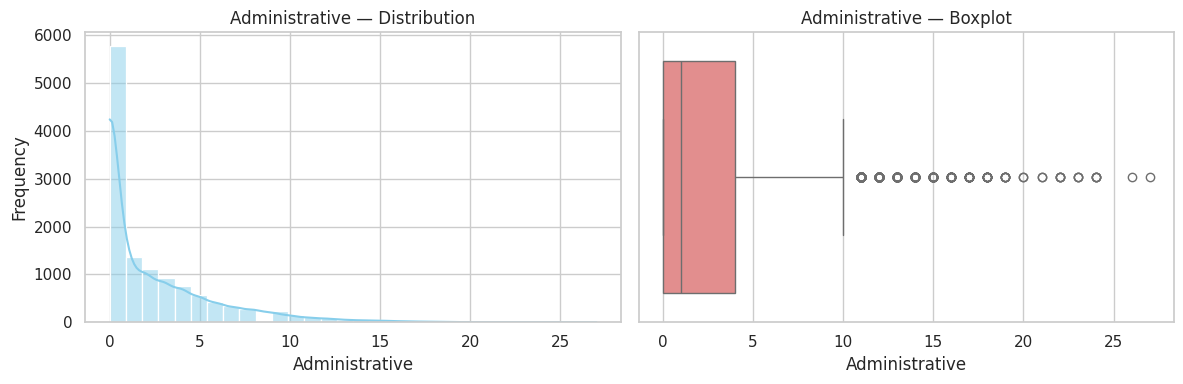

In [ ]:
plot_numeric_univariate(df, 'Administrative')

**Findings:**


- **Central Tendency and Spread:**
  The **mean (2.32)** is higher than the **median (1.0)**, indicating a **right-skewed distribution**. Most users visit **0–4 pages**, but the range extends to **27**.

- **Distribution Shape:**
  The histogram shows a **right-skewed, unimodal distribution**, with most users visiting **0–2 pages**. A long tail represents users visiting more pages.

- **Outliers:**
  The boxplot highlights outliers **above 10 pages**, suggesting unusual engagement (e.g., troubleshooting or navigation issues).

- **Core Insight:**
  Most users engage minimally with administrative pages, but a small group interacts extensively, possibly indicating specific needs or issues.

- **Modeling Consideration:**
  The **right-skewness** suggests a **log or square root transformation** may improve model performance.

- **Data Quality Note:**
  The high frequency of **0 visits** is typical but should be verified for data integrity. Outliers above 10 visits warrant further investigation.

### **3.1.2 Administrative Duration**

**Administrative_Duration** represents the total time (in seconds) users spend on administrative pages during their sessions. This metric helps assess user engagement with non-product content and can indicate navigation efficiency or potential issues.

#### **Key Questions:**
- What is the typical time users spend on administrative pages?
- Is the distribution symmetric or skewed?
- Are there outliers suggesting unusual behavior?





 Summary Statistics for 'Administrative_Duration'


,count,mean,std,min,25%,50%,75%,max
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75


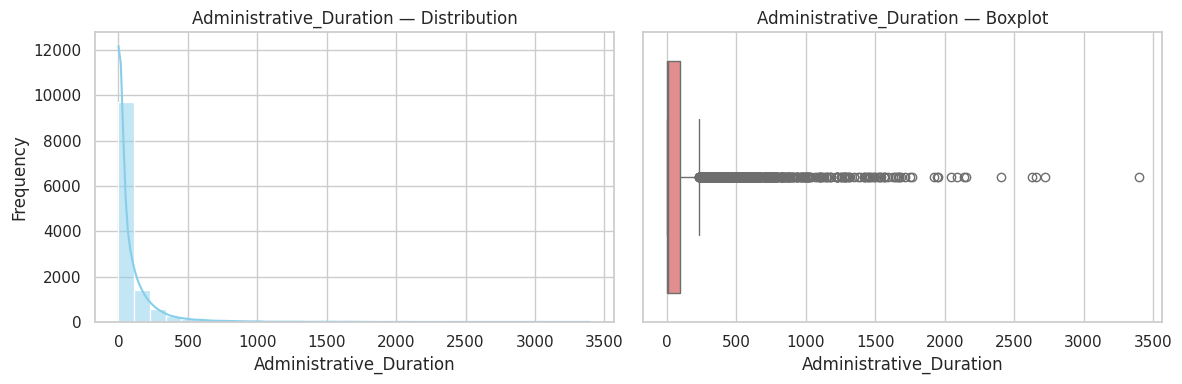

In [ ]:
plot_numeric_univariate(df, 'Administrative_Duration')

**Findings:**


- **Central Tendency and Spread:**
  The **mean duration (80.82 seconds)** is significantly higher than the **median (7.5 seconds)**, indicating a **strong right-skewed distribution**. Most users spend **0–93 seconds**, but the range extends up to **3398.75 seconds**.

- **Distribution Shape:**
  The histogram shows a **right-skewed, unimodal distribution**, with the majority of users spending **very little time** on administrative pages. A long tail represents a small group of users with much longer durations.

- **Outliers:**
  The boxplot highlights **outliers above ~500 seconds**, which may indicate users needing extensive support, troubleshooting, or experiencing navigation difficulties.

- **Core Insight:**
  Most users spend minimal time on administrative pages, but a small segment engages for prolonged periods, potentially signaling specific needs or issues.

- **Modeling Consideration:**
  The **right-skewness** suggests applying a **log transformation** to normalize the data for clustering and SVM models.

- **Data Quality Note:**
  The high frequency of **0 seconds** is expected but should be verified for data accuracy. Extreme outliers above 500 seconds may require further investigation to confirm their validity. This could represent genuine user behavior or data errors.

### **3.1.3 Informational Page Visits**

**Informational** tracks the number of informational pages (e.g., blogs, FAQs, guides) visited by users during their sessions. This analysis helps understand user engagement with informational content, which can inform content strategy and user experience improvements.


#### **Key Questions:**
- What is the typical number of informational pages visited?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?




 Summary Statistics for 'Informational'


,count,mean,std,min,25%,50%,75%,max
Informational,12330.0,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0


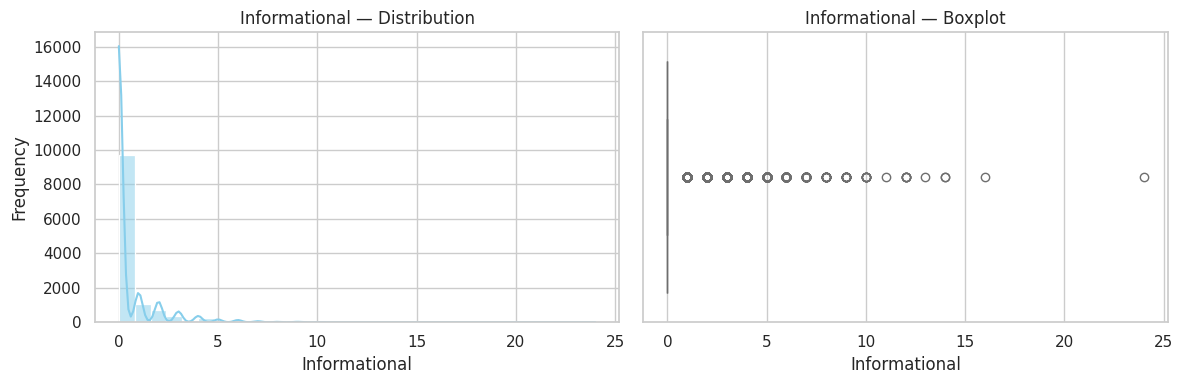

In [ ]:
plot_numeric_univariate(df, 'Informational')

**Findings:**

- **Central Tendency and Spread:**
  The **mean (0.50)** is higher than the **median (0.0)**, indicating a **right-skewed distribution**. The majority of users visit **0 informational pages**, but the range extends up to **24**.

- **Distribution Shape:**
  The histogram reveals a **highly right-skewed, unimodal distribution**, with most users visiting **0 pages**. A long tail represents a small number of users visiting multiple informational pages.

- **Outliers:**
  The boxplot identifies outliers **above 6 pages**, suggesting unusual engagement, such as in-depth research or navigation issues.

- **Core Insight:**
  Most users do not visit informational pages, but a small segment engages extensively, possibly indicating specific informational needs or interests.

- **Modeling Consideration:**
  The **right-skewness and excess zeros** suggest using a **log transformation (after adding a small constant)** or treating this as a **count variable** for modeling.

- **Data Quality Note:**
  The high frequency of **0 visits** is expected but should be validated. Outliers above 6 visits may require further investigation to confirm their legitimacy and understand user intent.

### **3.1.4 Informational Duration**

**Informational_Duration** represents the total time (in seconds) users spend on informational pages during their sessions. This metric helps assess how deeply users engage with informational content, which can guide content strategy and user experience improvements.


#### **Key Questions:**
- What is the typical time users spend on informational pages?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?





 Summary Statistics for 'Informational_Duration'


,count,mean,std,min,25%,50%,75%,max
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375


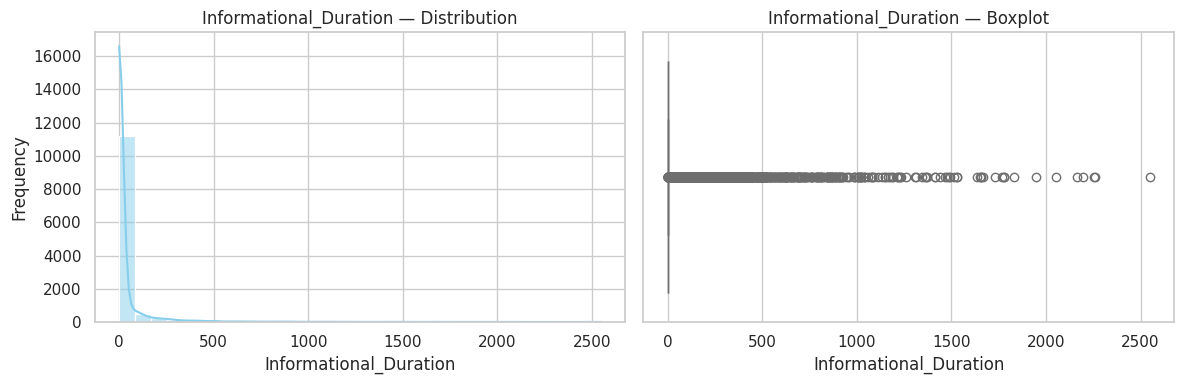

In [ ]:
plot_numeric_univariate(df, 'Informational_Duration')

**Findings:**

- **Central Tendency and Spread:**
  The **mean duration (34.47 seconds)** is significantly higher than the **median (0.0 seconds)**, indicating a **strong right-skewed distribution**. Most users spend **no time** on informational pages, but the range extends up to **2549.375 seconds**.

- **Distribution Shape:**
  The histogram shows a **highly right-skewed, unimodal distribution**, with the majority of users spending **no time** on informational pages. A long tail represents a small group of users with extended durations.

- **Outliers:**
  The boxplot highlights **outliers above ~200 seconds**, suggesting unusual engagement, such as in-depth reading, research, or navigation issues.

- **Core Insight:**
  Most users do not spend time on informational pages, but a small segment engages for prolonged periods, potentially indicating specific informational needs or interests.

- **Modeling Consideration:**
  The **right-skewness and excess zeros** suggest using a **log transformation (after adding a small constant)** or treating this as a **zero-inflated variable** for modeling.

- **Data Quality Note:**
  The high frequency of **0 seconds** is expected but should be validated. Extreme outliers above 200 seconds may require further investigation to confirm their legitimacy and understand user behavior.

### **3.1.5 Product-Related Page Visits**

**ProductRelated** tracks the number of product-related pages (e.g., product listings, details, reviews) visited by users during their sessions. This metric is crucial for understanding user interest in products and can inform marketing, recommendation systems, and website optimization.



#### **Key Questions:**
- What is the typical number of product-related pages visited?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?





 Summary Statistics for 'ProductRelated'


,count,mean,std,min,25%,50%,75%,max
ProductRelated,12330.0,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0


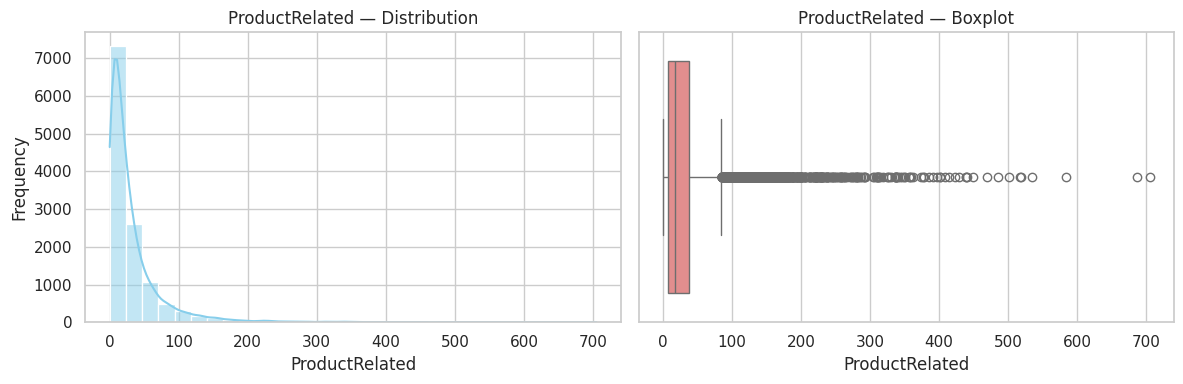

In [ ]:
plot_numeric_univariate(df, 'ProductRelated')

**Findings:**

- **Central Tendency and Spread:**
  The **mean (31.73 pages)** is close to the **median (18.0 pages)**, but the distribution is **right-skewed**. Most users visit between **7 and 38 pages**, while the range extends up to **705 pages**.

- **Distribution Shape:**
  The histogram shows a **right-skewed, unimodal distribution**, with most users visiting **a moderate number of product-related pages**. A long tail represents users who browse extensively.

- **Outliers:**
  The boxplot identifies **outliers above ~100 pages**, which may indicate highly engaged users, comparison shopping, or potential bot activity.

- **Core Insight:**
  Users generally browse a significant number of product-related pages, reflecting strong engagement with product content. The long tail suggests a smaller group of users with exceptionally high browsing activity.

- **Modeling Consideration:**
  The **right-skewness** suggests applying a **log transformation** to normalize the data for clustering and SVM models.

- **Data Quality Note:**
  The outliers above 100 pages should be investigated to confirm whether they represent genuine user behavior or potential data anomalies (e.g., bots or scraping activity). The minimum of **0 pages** is unusual and may warrant further validation.

### **3.1.6 Product-Related Duration**

**ProductRelated_Duration** represents the total time (in seconds) users spend on product-related pages during their sessions. This metric is key to understanding user engagement with product content and can guide recommendations, marketing, and website design.


#### **Key Questions:**
- What is the typical time users spend on product-related pages?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?





 Summary Statistics for 'ProductRelated_Duration'


,count,mean,std,min,25%,50%,75%,max
ProductRelated_Duration,12330.0,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223


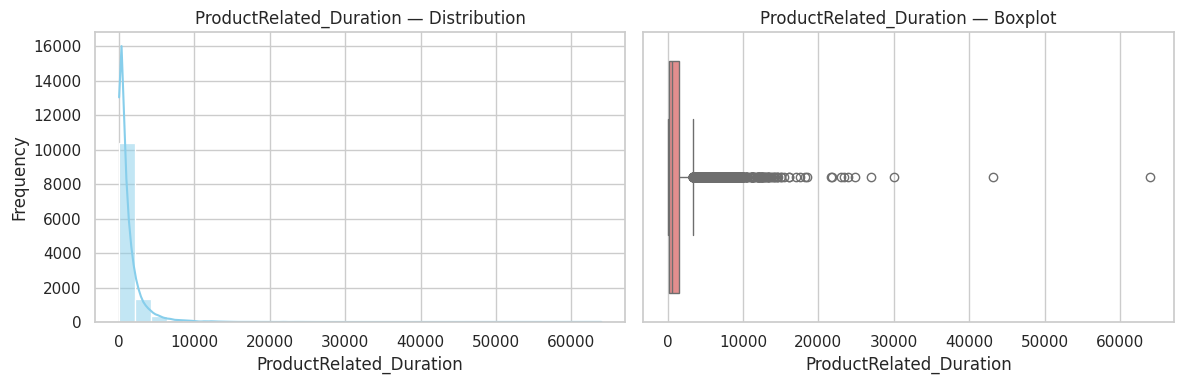

In [ ]:
plot_numeric_univariate(df, 'ProductRelated_Duration')

**Findings:**

- **Central Tendency and Spread:**
  The **mean duration (1194.75 seconds)** is higher than the **median (598.94 seconds)**, indicating a **right-skewed distribution**. Most users spend between **184 and 1484 seconds**, but the range extends up to **63973.52 seconds**.

- **Distribution Shape:**
  The histogram shows a **right-skewed, unimodal distribution**, with most users spending a moderate amount of time on product-related pages. A long tail represents users with exceptionally long durations.

- **Outliers:**
  The boxplot highlights **outliers above ~5000 seconds**, suggesting highly engaged users, extensive product research, or potential anomalies.

- **Core Insight:**
  Users generally spend a significant amount of time on product-related pages, reflecting strong engagement. The long tail indicates a smaller group of users with unusually high browsing durations.

- **Modeling Consideration:**
  The **right-skewness** suggests applying a **log transformation** to normalize the data for clustering and SVM models.

- **Data Quality Note:**
  Outliers above 5000 seconds should be investigated to confirm whether they represent genuine user behavior or potential data errors.

### **3.1.7 Bounce Rates**

**BounceRates** represents the proportion of single-page sessions (i.e., sessions where the user left the site from the entrance page without interacting further). This metric helps assess user engagement and the effectiveness of landing pages.


#### **Key Questions:**
- What is the typical bounce rate for sessions?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?


 Summary Statistics for 'BounceRates'


,count,mean,std,min,25%,50%,75%,max
BounceRates,12330.0,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2


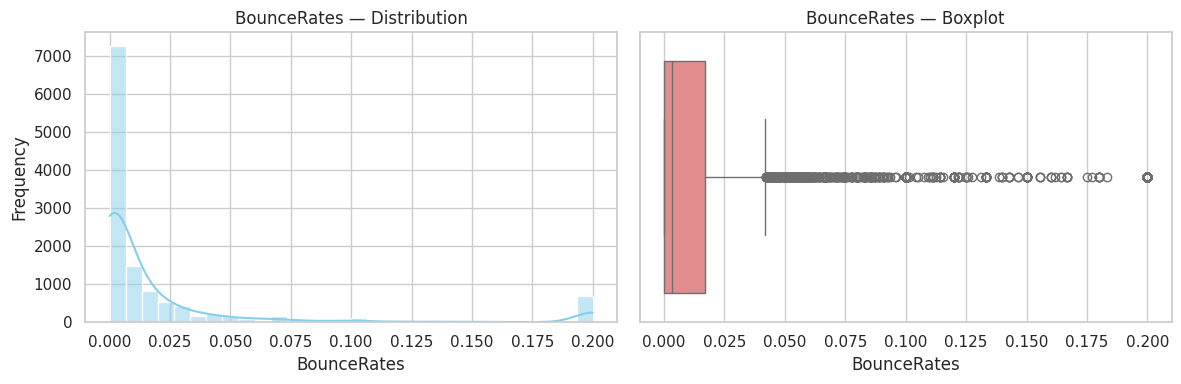

In [ ]:
plot_numeric_univariate(df, 'BounceRates')

**Findings:**

- **Central Tendency and Spread:**
  The **mean bounce rate (0.022)** is close to the **median (0.017)**, indicating a **right-skewed distribution**. Most sessions have a bounce rate between **0 and 0.031**, but the range extends up to **0.2**.

- **Distribution Shape:**
  The histogram reveals a **right-skewed, unimodal distribution**, with most sessions having a low bounce rate. A long tail represents sessions with higher bounce rates.

- **Outliers:**
  The boxplot identifies **outliers above ~0.075**, which may indicate landing page issues, poor user experience, or specific user behavior.

- **Core Insight:**
  The majority of sessions have a low bounce rate, suggesting effective engagement. However, a small segment of sessions shows higher bounce rates, potentially signaling areas for improvement.

- **Modeling Consideration:**
  The **right-skewness** suggests applying a **log transformation** or other normalization techniques for modeling.

- **Data Quality Note:**
  Outliers above 0.075 should be analyzed to understand their causes, such as page load issues or irrelevant content.

### **3.1.8 Exit Rates**

**ExitRates** represents the proportion of sessions that ended on a specific page after viewing one or more pages in a session. This metric helps identify pages where users frequently leave the site, which can indicate issues with content, usability, or user experience.

#### **Key Questions:**
- What is the typical exit rate for pages?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?





 Summary Statistics for 'ExitRates'


,count,mean,std,min,25%,50%,75%,max
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2


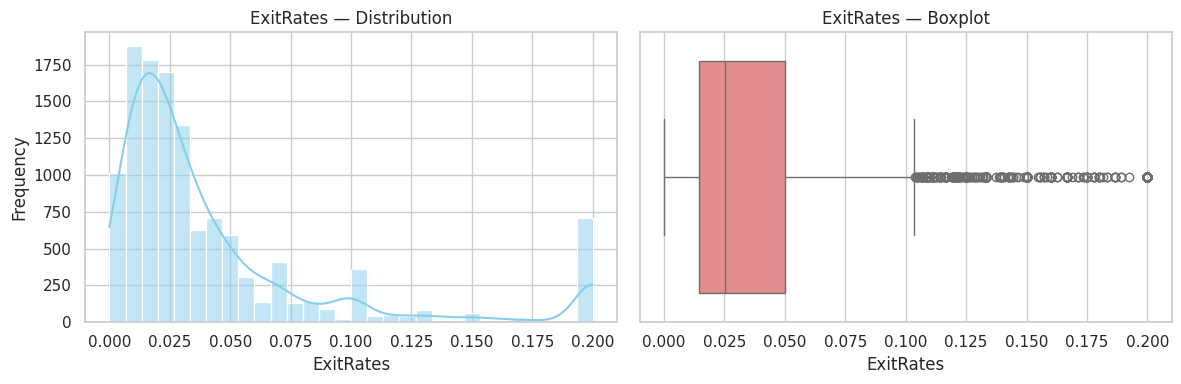

In [ ]:
plot_numeric_univariate(df, 'ExitRates')


**Findings:**

- **Central Tendency and Spread:**
  The **mean exit rate (0.043)** is slightly higher than the **median (0.026)**, indicating a **right-skewed distribution**. Most pages have exit rates between **0.013 and 0.052**, but the range extends up to **0.2**.

- **Distribution Shape:**
  The histogram shows a **right-skewed, multimodal distribution**, with most pages having low exit rates. Peaks in the distribution suggest clusters of pages with similar exit behavior.

- **Outliers:**
  The boxplot identifies **outliers above ~0.1**, which may indicate pages with usability issues, irrelevant content, or natural exit points (e.g., confirmation pages).

- **Core Insight:**
  Most pages have low exit rates, but some pages experience significantly higher exits. These pages should be reviewed for potential improvements in content or user experience.

- **Modeling Consideration:**
  The **right-skewness and multimodal nature** suggest using a **log transformation** or other normalization techniques for modeling.

- **Data Quality Note:**
  Outliers above 0.1 should be analyzed to determine whether they represent problematic pages or natural exit points in the user journey.

### **3.1.9 Page Values**

**PageValues** represents the average value of pages visited in a session, often used to assess the contribution of each page to the site's revenue or conversion goals. This metric helps identify high-value pages and optimize user pathways.


#### **Key Questions:**
- What is the typical page value?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?


 Summary Statistics for 'PageValues'


,count,mean,std,min,25%,50%,75%,max
PageValues,12330.0,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742


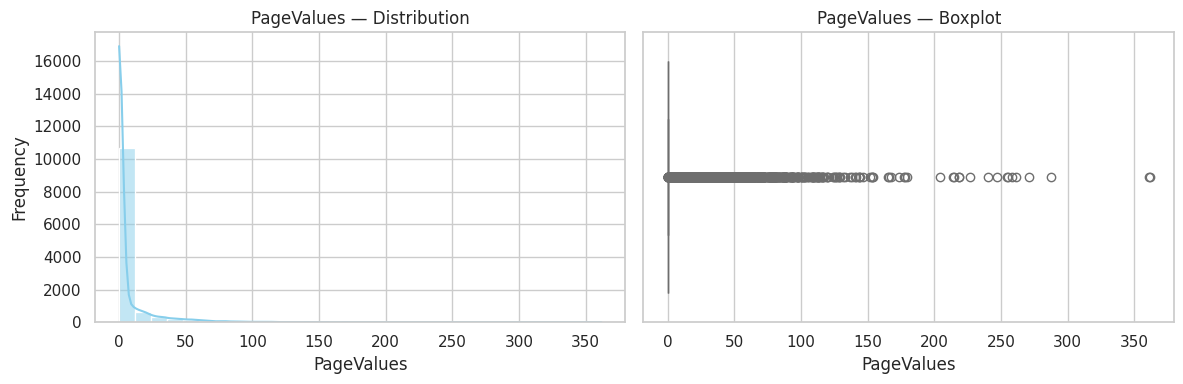

In [ ]:
plot_numeric_univariate(df, 'PageValues')

**Findings:**

- **Central Tendency and Spread:**
  The **mean page value (5.88)** is significantly higher than the **median (0.0)**, indicating a **strong right-skewed distribution**. Most pages have a value of **0**, but the range extends up to **374.28**.

- **Distribution Shape:**
  The histogram reveals a **highly right-skewed, unimodal distribution**, with the majority of pages having **low or zero value**. A long tail represents high-value pages.

- **Outliers:**
  The boxplot highlights **outliers above ~20**, which likely represent key conversion or high-revenue pages.

- **Core Insight:**
  A small number of pages contribute disproportionately to the site's value, suggesting a focus on optimizing and promoting these high-value pages.

- **Modeling Consideration:**
  The **right-skewness and excess zeros** suggest using a **log transformation (after adding a small constant)** or treating this as a **zero-inflated variable** for modeling.

- **Data Quality Note:**
  The high frequency of **0 values** is expected but should be validated. Outliers above 20 should be analyzed to understand their characteristics and leverage their success.

### **3.1.10 Special Day**

**SpecialDay** indicates the proximity of a user's session to a special day (e.g., holidays, promotions, or events), with values ranging from **0 (no special day)** to **1 (the actual special day)**. This metric helps assess the impact of special occasions on user behavior and engagement.

#### **Key Questions:**
- What is the typical proximity of sessions to special days?
- Is the distribution symmetric or skewed?
- Are there outliers indicating unusual behavior?





 Summary Statistics for 'SpecialDay'


,count,mean,std,min,25%,50%,75%,max
SpecialDay,12330.0,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


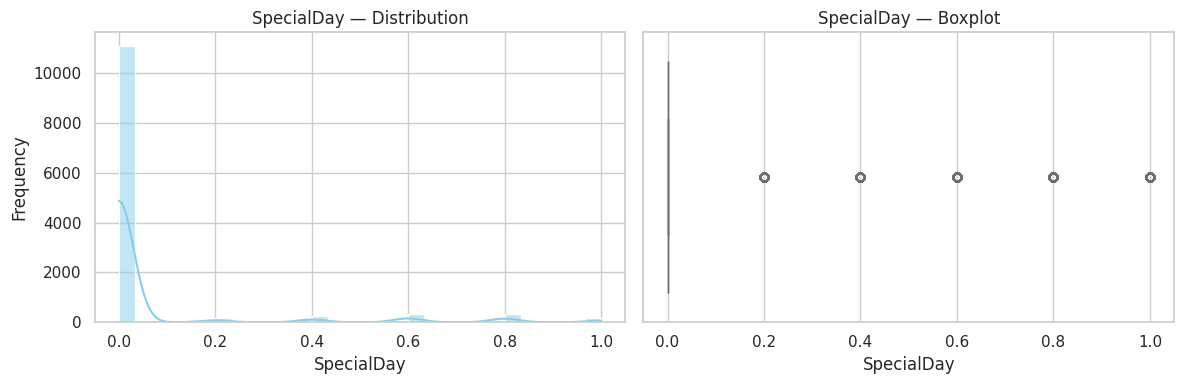

In [ ]:
plot_numeric_univariate(df, 'SpecialDay')

**Findings:**

- **Central Tendency and Spread:**
  The **mean (0.061)** is higher than the **median (0.0)**, indicating a **right-skewed distribution**. Most sessions occur on **non-special days (0.0)**, but some sessions are close to or on special days.

- **Distribution Shape:**
  The histogram shows a **highly right-skewed, unimodal distribution**, with the vast majority of sessions having **no association with special days**. A small peak is observed near **1.0**, representing sessions on special days.

- **Outliers:**
  The boxplot highlights **outliers above ~0.4**, which represent sessions occurring close to special days.

- **Core Insight:**
  Most user sessions are not associated with special days, but a small segment of sessions occurs near or on special days. This suggests potential opportunities for targeted promotions or campaigns during these periods.

- **Modeling Consideration:**
  The **right-skewness and binary-like nature** of this variable suggest it could be treated as a **categorical or binary feature** (e.g., "IsSpecialDay") for modeling purposes.

- **Data Quality Note:**
  The high frequency of **0 values** is expected, as most sessions occur on regular days. The outliers near **1.0** should be analyzed to understand their impact on user behavior and conversion rates.

## **3.2 Univariate Analysis — Categorical Variables**

After completing the numeric feature analysis, our next step focuses on **categorical variables** — essential for identifying dominant classes, detecting imbalances, and planning suitable encoding methods for machine learning models such as KNN and SVM.

To ensure consistency and efficiency, we define a reusable function named **`plot_categorical_univariate()`**. This function standardizes the process of analyzing and visualizing categorical variables across the dataset.

The function performs the following key tasks:

1. **Calculate Frequency and Percentage** – It computes the count of each unique category using `.value_counts()` and calculates their corresponding percentages relative to the total dataset size.
2. **Display a Summary Table** – The function displays a clean tabular summary showing category counts and percentages, with an optional `top` parameter to limit output to the most frequent categories.
3. **Generate a Bar Plot** – A bar chart is produced using Seaborn to visualize category frequencies, enabling quick comparison and identification of skewed or dominant categories.

This function provides a consistent and clear overview of categorical distributions, allowing for data-driven decisions in preprocessing and model preparation.


In [ ]:
# Univariate Analysis: Categorical


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

def plot_categorical_univariate(df, col, top=None):
    """Displays frequency table and barplot for one categorical variable."""
    print(f"\n Frequency Table for '{col}'")
    vc = df[col].value_counts(dropna=False).sort_values(ascending=False)

    if top is not None:
        vc = vc.head(top)

    pct = (vc / len(df) * 100).round(2)
    tab = pd.DataFrame({'Count': vc, 'Percent (%)': pct})
    display(tab)

    plt.figure(figsize=(7,4))
    sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")
    plt.title(f"{col} — Frequency Distribution")
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### **3.2.1 Month**

**Month** is a categorical feature that describes the month in which a user session occurred. Analyzing this variable helps us understand seasonal trends in user behavior, such as peak shopping periods or variations in engagement throughout the year. This information is valuable for feature engineering, as seasonal patterns may influence purchase decisions and website interactions.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of user sessions by month.




 Frequency Table for 'Month'


,Count,Percent (%)
Month,,
May,3364,27.28
Nov,2998,24.31
Mar,1907,15.47
Dec,1727,14.01
Oct,549,4.45
Sep,448,3.63
Aug,433,3.51
Jul,432,3.50
June,288,2.34


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


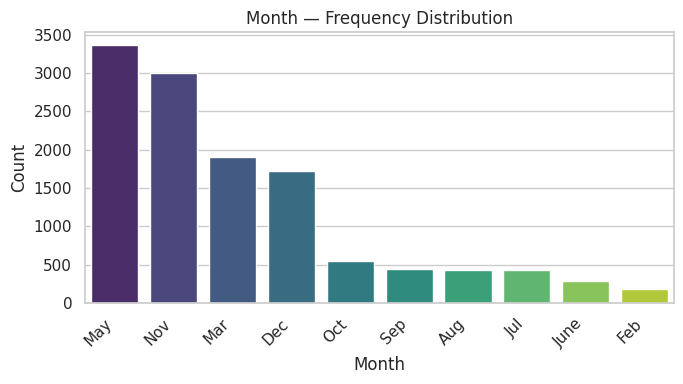

In [ ]:
plot_categorical_univariate(df, 'Month')


**Main Findings:**

- **Three Dominant Months:**
  The dataset is primarily composed of sessions from **May (27.28%)**, **November (24.31%)**, and **March (15.47%)**. These months collectively account for **67.06%** of the total sessions, indicating potential seasonal peaks in user activity.

- **Moderate and Low Activity Months:**
  **December (14.01%)** also shows notable activity, while **October (4.45%)**, **September (3.83%)**, **August (3.51%)**, and **July (3.50%)** have moderate session counts. **February (1.49%)** has the lowest activity, suggesting it may be an off-peak period.

- **Implications for Modeling:**
  The dominant months (**May, November, and March**) likely reflect seasonal trends, such as holiday shopping or promotions, and can provide a strong signal for models. Months with lower activity, such as **February**, may not contribute as significantly to predictive power and could be considered for grouping with similar low-activity months to reduce noise and improve model robustness.

### **3.2.2 VisitorType**

**VisitorType** is a categorical feature that describes the type of visitor accessing the website, such as whether they are a **Returning_Visitor**, **New_Visitor**, or fall into another category. Analyzing this variable helps us understand the composition of the website's audience, which can inform marketing strategies, user experience design, and customer retention efforts.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of visitor types.




 Frequency Table for 'VisitorType'


,Count,Percent (%)
VisitorType,,
Returning_Visitor,10551,85.57
New_Visitor,1694,13.74
Other,85,0.69


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


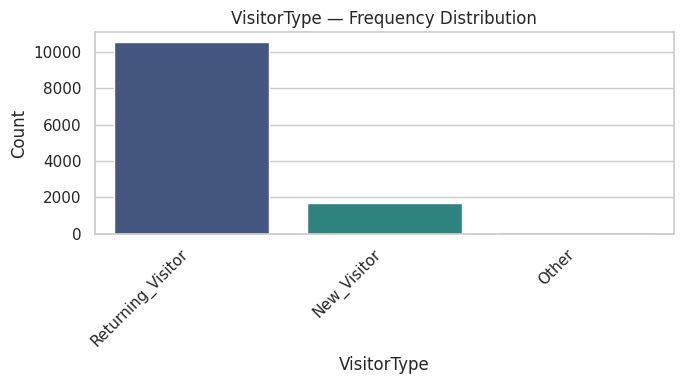

In [ ]:
plot_categorical_univariate(df, 'VisitorType')


**Main Findings:**

- **One Dominant Category:**
  The dataset is overwhelmingly composed of **Returning_Visitors**, who represent **85.57%** of the total sessions. This indicates a strong base of repeat users, which is valuable for customer retention and loyalty strategies.

- **Secondary Category:**
  **New_Visitors** account for **13.74%** of the sessions, suggesting a steady influx of new users. This group is important for growth and acquisition strategies.

- **Rare Category:**
  The **Other** category is exceptionally rare, representing only **0.69%** of the sessions. This category may include miscellaneous or undefined visitor types and holds negligible predictive power.

- **Implications for Modeling:**
  The dominance of **Returning_Visitors** will likely provide a strong signal for models, as returning users may exhibit different behaviors and conversion patterns compared to new visitors. The **Other** category, due to its rarity, should be considered for removal or grouping with another category to reduce noise and improve model robustness. This will help create a more reliable and interpretable feature.

### **3.2.3 Weekend**

**Weekend** is a categorical feature that indicates whether a user session occurred on a weekend (`True`) or a weekday (`False`). Analyzing this variable helps us understand differences in user behavior between weekends and weekdays, which can inform marketing strategies, website optimization, and resource allocation.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of sessions by weekend status.




 Frequency Table for 'Weekend'


,Count,Percent (%)
Weekend,,
False,9462,76.74
True,2868,23.26


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


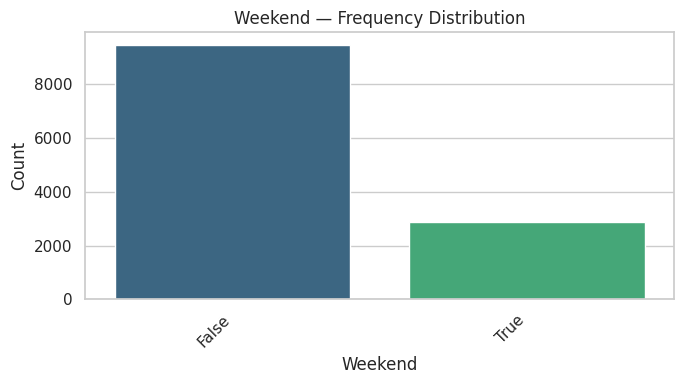

In [ ]:
plot_categorical_univariate(df, 'Weekend')

**Main Findings:**

- **One Dominant Category:**
  The dataset is predominantly composed of sessions that occurred on **weekdays (`False`)**, representing **76.74%** of the total sessions. This suggests that user activity is higher on weekdays, which may reflect typical browsing and purchasing behavior during workdays.

- **Secondary Category:**
  Sessions on **weekends (`True`)** account for **23.26%** of the total. Although less frequent, weekend sessions may exhibit different behaviors, such as longer browsing times or different product interests.

- **Implications for Modeling:**
  The dominance of **weekday sessions** suggests that models should account for potential differences in user behavior between weekdays and weekends. This variable can be a useful feature for segmentation and personalized marketing strategies.
  Since there are only two categories, no grouping or removal is necessary, but the imbalance should be considered during model training.

### **3.2.4 OperatingSystems**

**OperatingSystems** is a categorical feature that indicates the operating system used by visitors during their sessions. Analyzing this variable helps us understand the distribution of operating systems among users, which can inform website optimization, compatibility testing, and targeted marketing strategies.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of sessions by operating system.


 Frequency Table for 'OperatingSystems'


,Count,Percent (%)
OperatingSystems,,
2,6601,53.54
1,2585,20.97
3,2555,20.72
4,478,3.88
8,79,0.64
6,19,0.15
7,7,0.06
5,6,0.05


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


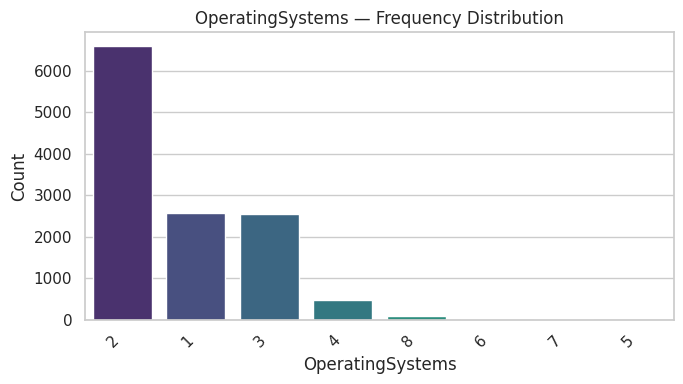

In [ ]:
plot_categorical_univariate(df, 'OperatingSystems')




**Main Findings:**

- **One Dominant Category:**
  The dataset is predominantly composed of sessions from users using **OperatingSystem 2**, representing **53.54%** of the total sessions. This indicates that more than half of the users are using this operating system, which should be prioritized for compatibility and optimization.

- **Two Secondary Categories:**
  **OperatingSystem 1 (20.97%)** and **OperatingSystem 3 (20.72%)** are also significant, collectively accounting for **41.69%** of the sessions. These operating systems should also be considered for targeted optimization and testing.

- **Rare Categories:**
  **OperatingSystem 4 (3.88%)**, **OperatingSystem 8 (0.64%)**, **OperatingSystem 6 (0.15%)**, **OperatingSystem 7 (0.06%)**, and **OperatingSystem 5 (0.05%)** are present but rare. These categories may not provide significant predictive power and could be considered for grouping into an "Other" category to reduce noise and improve model robustness.

- **Implications for Modeling:**
  The dominance of **OperatingSystem 2** suggests that models should account for potential differences in user behavior across operating systems. Rare operating systems should be grouped to avoid sparsity and improve model performance. This will help create a more reliable and interpretable feature for analysis.

### **3.2.5 Browser**

**Browser** is a categorical feature that indicates the web browser used by visitors during their sessions. Analyzing this variable helps us understand the distribution of browsers among users, which can inform website compatibility testing, optimization efforts, and targeted improvements to enhance user experience.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of sessions by browser type.



 Frequency Table for 'Browser'


,Count,Percent (%)
Browser,,
2,7961,64.57
1,2462,19.97
4,736,5.97
5,467,3.79
6,174,1.41
10,163,1.32
8,135,1.09
3,105,0.85
13,61,0.49


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


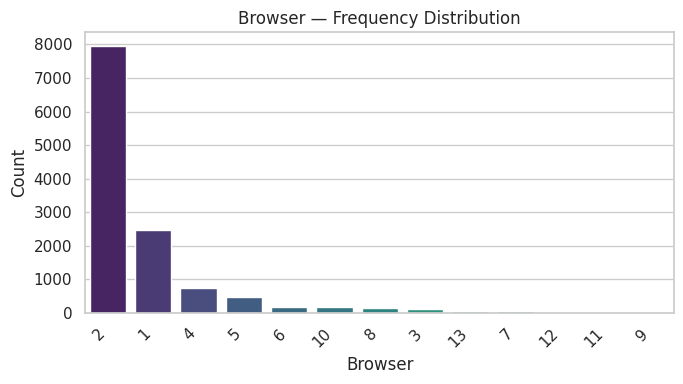

In [ ]:
plot_categorical_univariate(df, 'Browser')




**Main Findings:**


- **One Dominant Browser:**
  The dataset is predominantly composed of sessions from users using **Browser 2**, representing **64.57%** of the total sessions. This indicates that a significant majority of users are using this browser, which should be prioritized for compatibility and optimization.

- **Secondary Browsers:**
  **Browser 1 (19.97%)** is the second most used browser, followed by **Browser 4 (5.97%)** and **Browser 5 (3.79%)**. These browsers collectively account for a significant portion of sessions and should also be considered for optimization and testing.

- **Rare Browsers:**
  **Browser 6 (1.41%)**, **Browser 10 (1.32%)**, **Browser 8 (1.09%)**, **Browser 3 (0.85%)**, **Browser 13 (0.49%)**, **Browser 7 (0.40%)**, **Browser 12 (0.08%)**, **Browser 11 (0.05%)**, and **Browser 9 (0.01%)** are present but rare. These browsers may not provide significant predictive power and could be considered for grouping into an "Other" category to reduce noise and improve model robustness.

- **Implications for Modeling:**
  The dominance of **Browser 2** suggests that models should account for potential differences in user behavior across browsers. Rare browsers should be grouped to avoid sparsity and improve model performance, creating a more reliable and interpretable feature for analysis.

### **3.2.6 Region**

**Region** is a categorical feature that indicates the geographic region from which users accessed the website. Analyzing this variable helps us understand the distribution of users across different regions, which can inform targeted marketing strategies, regional promotions, and localization efforts.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of sessions by region.



 Frequency Table for 'Region'


,Count,Percent (%)
Region,,
1,4780,38.77
3,2403,19.49
4,1182,9.59
2,1136,9.21
6,805,6.53
7,761,6.17
9,511,4.14
8,434,3.52
5,318,2.58


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


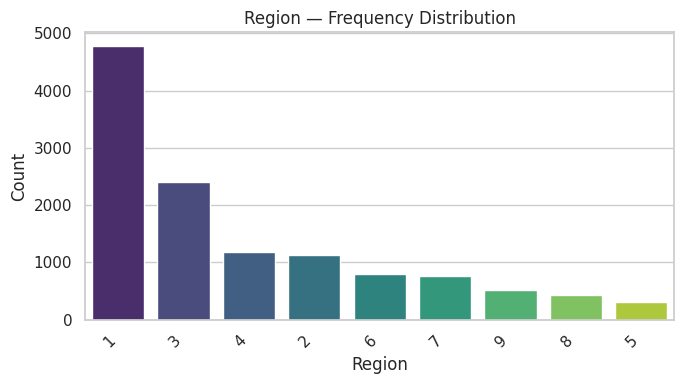

In [ ]:
plot_categorical_univariate(df, 'Region')

**Main Findings:**

- **One Dominant Region:**
  The dataset is predominantly composed of sessions from users in **Region 1**, representing **38.77%** of the total sessions. This indicates that a significant portion of the user base is located in this region, which should be prioritized for targeted marketing and optimization efforts.

- **Secondary Regions:**
  **Region 3 (19.49%)** and **Region 4 (9.50%)** are also significant, followed closely by **Region 2 (9.21%)**. These regions collectively account for a substantial portion of sessions and should be considered for regional strategies and localization.

- **Moderate and Low Activity Regions:**
  **Region 6 (6.53%)**, **Region 7 (6.34%)**, **Region 9 (4.14%)**, and **Region 8 (3.52%)** have moderate session counts, while **Region 5 (2.58%)** has the lowest activity. These regions may not provide as significant predictive power and could be considered for grouping into an "Other" category to reduce noise and improve model robustness.

- **Implications for Modeling:**
  The dominance of **Region 1** suggests that models should account for potential differences in user behavior across regions. Regions with lower activity should be grouped to avoid sparsity and improve model performance, creating a more reliable and interpretable feature for analysis. This can help tailor marketing strategies and user experience improvements to specific regions.

### **3.2.7 TrafficType**

**TrafficType** is a categorical feature that indicates the source or type of traffic that directed users to the website. Analyzing this variable helps us understand the distribution of traffic sources, which can inform marketing strategies, budget allocation, and optimization of user acquisition channels.

The following analysis generates a frequency table and a bar plot to provide a clear visual and numerical breakdown of sessions by traffic type.


 Frequency Table for 'TrafficType'


,Count,Percent (%)
TrafficType,,
2,3913,31.74
1,2451,19.88
3,2052,16.64
4,1069,8.67
13,738,5.99
10,450,3.65
6,444,3.60
8,343,2.78
5,260,2.11


/tmp/ipython-input-1401269774.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


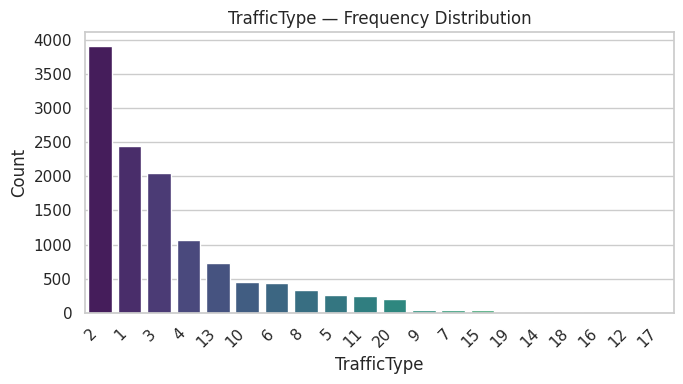

In [ ]:
plot_categorical_univariate(df, 'TrafficType')

**Main Findings:**

- **One Dominant Traffic Type:**
  The dataset is predominantly composed of sessions from **TrafficType 2**, representing **31.74%** of the total sessions. This indicates that a significant portion of the traffic is coming from this source, which should be prioritized for further analysis and optimization.

- **Secondary Traffic Types:**
  **TrafficType 1 (19.88%)** and **TrafficType 3 (16.64%)** are also significant, collectively accounting for **36.52%** of the sessions. These traffic sources should be considered for targeted strategies and further optimization.

- **Moderate Traffic Types:**
  **TrafficType 4 (8.87%)**, **TrafficType 13 (5.99%)**, **TrafficType 10 (3.65%)**, **TrafficType 6 (3.60%)**, **TrafficType 8 (2.78%)**, **TrafficType 5 (2.11%)**, and **TrafficType 11 (2.00%)** have moderate session counts. These sources may still provide valuable insights and should be monitored.

- **Rare Traffic Types:**
  **TrafficType 20 (1.61%)**, **TrafficType 9 (0.34%)**, **TrafficType 7 (0.32%)**, **TrafficType 15 (0.31%)**, **TrafficType 19 (0.14%)**, **TrafficType 14 (0.11%)**, **TrafficType 18 (0.08%)**, **TrafficType 16 (0.02%)**, **TrafficType 12 (0.01%)**, and **TrafficType 17 (0.01%)** are present but rare. These traffic sources may not provide significant predictive power and could be considered for grouping into an "Other" category to reduce noise and improve model robustness.

- **Implications for Modeling:**
  The dominance of **TrafficType 2** suggests that models should account for potential differences in user behavior across traffic sources. Rare traffic types should be grouped to avoid sparsity and improve model performance, creating a more reliable and interpretable feature for analysis. This can help optimize marketing strategies and user acquisition efforts.

## **3.3 Bivariate Analysis**

**A. Numeric Variables vs Numeric Variables**

### **3.3.1 ProductRelated vs ProductRelated_Duration**
**Objective:**
This analysis examines the relationship between **ProductRelated** (number of product-related actions, e.g., views, clicks) and **ProductRelated_Duration** (time spent on product-related activities). Understanding this relationship can reveal how engagement with product-related content correlates with the depth of interaction, potentially indicating user interest or purchase intent.

**Key Questions:**
- Is there a pattern in how **ProductRelated_Duration** changes with an increase in **ProductRelated** actions?
- Do users who engage more with product-related content spend significantly more time on these activities?
- Are there clusters or outliers that suggest distinct user behaviors?

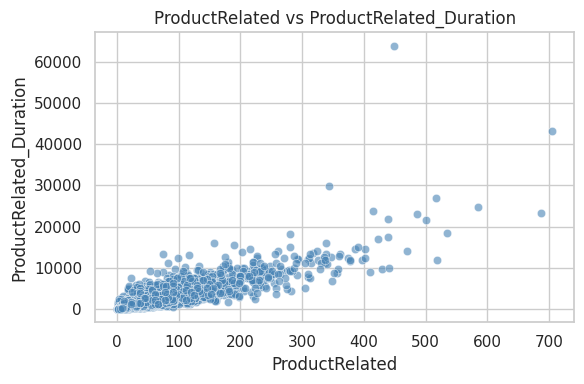

In [ ]:
# Numeric vs Numeric

import seaborn as sns
import matplotlib.pyplot as plt

# ProductRelated vs ProductRelated_Duration
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated', y='ProductRelated_Duration', data=df, alpha=0.6, color='steelblue')
plt.title("ProductRelated vs ProductRelated_Duration")
plt.xlabel("ProductRelated")
plt.ylabel("ProductRelated_Duration")
plt.tight_layout()
plt.show()

**Findings:**
The scatter plot visualizes the distribution of **ProductRelated_Duration** across different levels of **ProductRelated** actions.

- **Trends and Patterns:**
  - Most users cluster at lower values for both **ProductRelated** and **ProductRelated_Duration**, indicating that casual browsing is common.
  - A positive trend is observed: as **ProductRelated** actions increase, **ProductRelated_Duration** tends to rise, suggesting deeper engagement with product content.
- **Notable Observations:**
  - A few users exhibit extremely high **ProductRelated_Duration** for moderate to high **ProductRelated** actions, indicating intense interest or detailed exploration.
  - The spread of **ProductRelated_Duration** widens with more **ProductRelated** actions, reflecting diverse user behaviors at higher engagement levels.
- **Outliers or Anomalies:**
  - Outliers with very high **ProductRelated_Duration** but relatively low **ProductRelated** actions may represent users who spend a lot of time on a few product-related activities, possibly due to detailed comparisons or indecision.

**Implications for Modeling:**
- **ProductRelated** and **ProductRelated_Duration** together can serve as indicators of user engagement and potential purchase intent.
- Consider segmenting users based on these variables to tailor recommendations or marketing strategies.
- Address outliers carefully, as they may represent unique user behaviors or data anomalies.

---

### **3.3.2 Informational vs Informational_Duration**
**Objective:**
This analysis explores the relationship between **Informational** (number of informational actions, e.g., page views, searches) and **Informational_Duration** (time spent on informational activities). The goal is to understand how users engage with informational content and whether deeper engagement correlates with longer durations.

**Key Questions:**
- Does the time spent on informational activities increase with more informational actions?
- Are there distinct clusters or outliers indicating unique user behaviors?

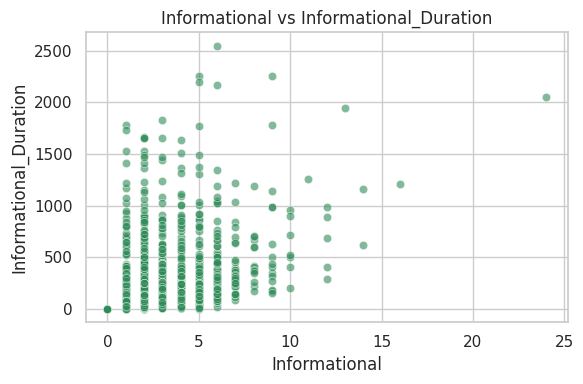

In [ ]:
# Informational vs Informational_Duration
plt.figure(figsize=(6,4))
sns.scatterplot(x='Informational', y='Informational_Duration', data=df, alpha=0.6, color='seagreen')
plt.title("Informational vs Informational_Duration")
plt.xlabel("Informational")
plt.ylabel("Informational_Duration")
plt.tight_layout()
plt.show()



**Findings:**
- **Trends:**
  - Most users cluster at lower values for both variables, suggesting brief informational interactions are common.
  - A positive trend is visible: users with more informational actions generally spend more time, indicating deeper engagement.
- **Notable Observations:**
  - A few users spend significantly more time on informational activities, even with fewer actions, possibly due to in-depth reading or research.
- **Outliers:**
  - Outliers with high **Informational_Duration** but low **Informational** actions may represent users conducting detailed research or facing navigation challenges.

**Implications:**
- **Informational** and **Informational_Duration** can help identify user engagement levels and inform content strategy or user experience improvements.

### **3.3.3 Administrative vs Administrative_Duration**
**Objective:**
This analysis explores the relationship between **Administrative** (number of administrative actions, such as account updates or settings changes) and **Administrative_Duration** (time spent on these actions). The goal is to understand how user engagement with administrative tasks correlates with the time spent on them.

**Key Questions:**
- How does **Administrative_Duration** vary with the number of **Administrative** actions?
- Are there distinct patterns or outliers in user behavior for administrative tasks?

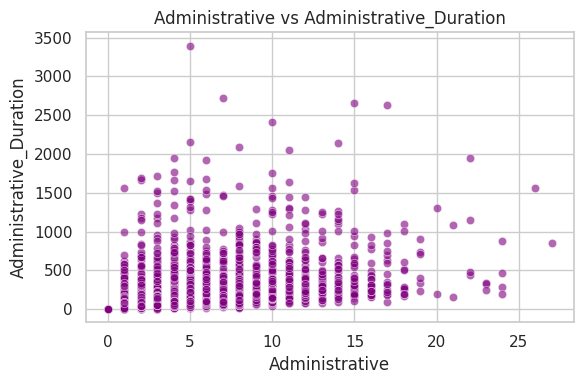

In [ ]:
# Administrative vs Administrative_Duration
plt.figure(figsize=(6,4))
sns.scatterplot(x='Administrative', y='Administrative_Duration', data=df, alpha=0.6, color='purple')
plt.title("Administrative vs Administrative_Duration")
plt.xlabel("Administrative")
plt.ylabel("Administrative_Duration")
plt.tight_layout()
plt.show()




**Findings:**
The scatter plot visualizes the distribution of **Administrative_Duration** across different levels of **Administrative** actions.
- **Trends and Patterns:**
  - Most users cluster at lower values for both **Administrative** actions and **Administrative_Duration**, indicating brief interactions.
  - A weak positive trend suggests that users who perform more administrative actions tend to spend slightly more time on these tasks.
- **Notable Observations:**
  - A few users spend significantly more time on administrative tasks, even with fewer actions, possibly due to complex account management or technical issues.
- **Outliers or Anomalies:**
  - Outliers with high **Administrative_Duration** but low **Administrative** actions may represent users facing difficulties or conducting detailed administrative work.



### **3.3.4 BounceRates vs ExitRates**
**Objective:**
This analysis examines the relationship between **BounceRates** (percentage of single-page sessions) and **ExitRates** (percentage of exits from a page). The goal is to understand how these metrics correlate and what they reveal about user engagement and page performance.

**Key Questions:**
- Is there a correlation between **BounceRates** and **ExitRates**?
- Do pages with high bounce rates also tend to have high exit rates?


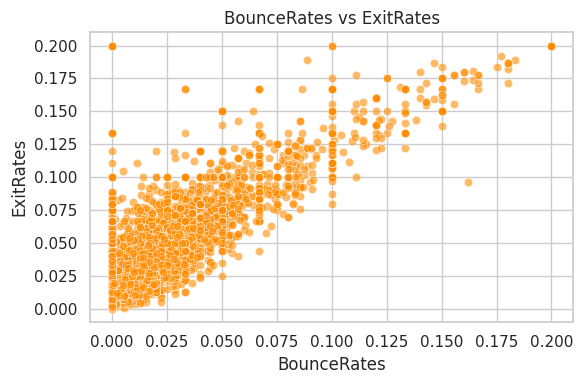

In [ ]:
# BounceRates vs ExitRates
plt.figure(figsize=(6,4))
sns.scatterplot(x='BounceRates', y='ExitRates', data=df, alpha=0.6, color='darkorange')
plt.title("BounceRates vs ExitRates")
plt.xlabel("BounceRates")
plt.ylabel("ExitRates")
plt.tight_layout()
plt.show()


**Findings:**
The scatter plot visualizes the relationship between **BounceRates** and **ExitRates**.
- **Trends and Patterns:**
  - A positive correlation is observed: pages with higher **BounceRates** tend to have higher **ExitRates**, indicating users often leave the site entirely after viewing a single page.
- **Notable Observations:**
  - Most data points cluster at lower values, suggesting that many pages have both low bounce and exit rates.
  - Some pages stand out with significantly higher rates, signaling potential issues with content relevance or user experience.
- **Outliers or Anomalies:**
  - Pages with unusually high **BounceRates** and **ExitRates** may require further investigation to improve engagement and retention.

**A. Categorical Variables vs Numeric Variables**

### **3.3.5 PageValues vs ProductRelated_Duration**
**Objective:**
This analysis explores the relationship between **PageValues** (average value of pages visited in a session) and **ProductRelated_Duration** (time spent on product-related activities). The goal is to understand how the value of pages visited correlates with the depth of engagement in product-related content.

**Key Questions:**
- How does **ProductRelated_Duration** vary with different **PageValues**?
- Are there patterns indicating that higher **PageValues** lead to longer engagement with product-related content?

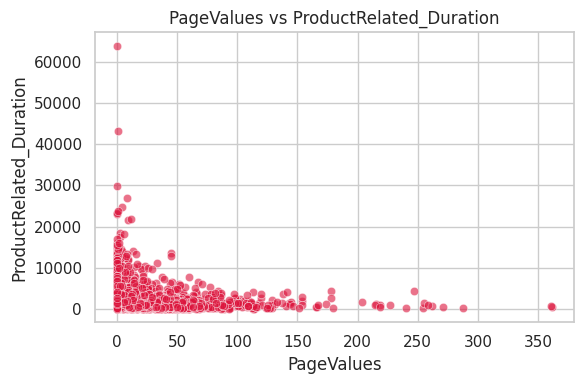

In [ ]:
# PageValues vs ProductRelated_Duration
plt.figure(figsize=(6,4))
sns.scatterplot(x='PageValues', y='ProductRelated_Duration', data=df, alpha=0.6, color='crimson')
plt.title("PageValues vs ProductRelated_Duration")
plt.xlabel("PageValues")
plt.ylabel("ProductRelated_Duration")
plt.tight_layout()
plt.show()



**Findings:**
The scatter plot visualizes the distribution of **ProductRelated_Duration** across different **PageValues**.
- **Trends and Patterns:**
  - Most sessions cluster at lower **PageValues** and **ProductRelated_Duration**, indicating brief interactions with lower-value pages.
  - A small number of sessions with high **PageValues** show a wide range of **ProductRelated_Duration**, suggesting that high-value pages can either capture prolonged engagement or result in quick exits.
- **Notable Observations:**
  - Outliers with extremely high **ProductRelated_Duration** and **PageValues** may represent users deeply engaged with high-value product content.

### **3.3.6 PageValues by Month**
**Objective:**
This analysis explores the distribution of **PageValues** (average value of pages visited in a session) across different months of the year. The goal is to identify seasonal trends or variations in page value, which can provide insights into user behavior and engagement patterns throughout the year.

**Key Questions:**
- How do **PageValues** vary across different months?
- Are there specific months with significantly higher or lower **PageValues**?
- What potential seasonal trends or anomalies can be observed?

/tmp/ipython-input-1002793725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='PageValues', data=df, palette='Set3')


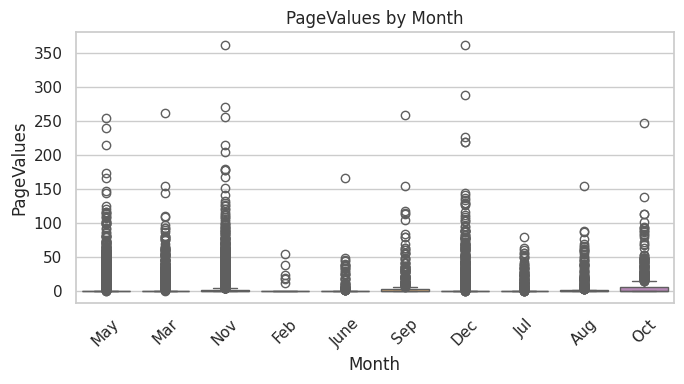

In [ ]:
# Month vs PageValues
plt.figure(figsize=(7,4))
sns.boxplot(x='Month', y='PageValues', data=df, palette='Set3')
plt.title("PageValues by Month")
plt.xlabel("Month")
plt.ylabel("PageValues")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




**Findings:**
The boxplot visualizes the distribution of **PageValues** for each month.
- **Trends and Patterns:**
  - **PageValues** show considerable variation across months, with some months like **November, February, and May** exhibiting higher median values and a wider spread.
  - Months like **June, July, and August** tend to have lower median **PageValues**, indicating potentially lower user engagement or page value during these periods.
- **Notable Observations:**
  - **November** stands out with the highest median **PageValues** and several outliers, suggesting increased user activity or higher-value page visits, possibly due to seasonal events or promotions.
  - **February** and **May** also show relatively high **PageValues**, indicating periods of heightened user engagement.
- **Outliers or Anomalies:**
  - Outliers in months like **November** and **December** may represent specific high-value sessions or seasonal spikes in user activity.
- **Implications:**
  - Understanding these monthly trends can help tailor marketing strategies, content planning, and promotions to capitalize on high-value periods and improve engagement during lower-value months.

### **3.3.7 ProductRelated_Duration by VisitorType**
**Objective:**
This analysis examines the relationship between **VisitorType** (New Visitor, Returning Visitor, Other) and **ProductRelated_Duration** (time spent on product-related activities). The goal is to understand how different types of visitors engage with product-related content and whether visitor type influences the depth of interaction.

**Key Questions:**
- How does **ProductRelated_Duration** differ among **New Visitors**, **Returning Visitors**, and **Other** visitor types?
- Are there noticeable trends or patterns in engagement duration based on visitor type?

/tmp/ipython-input-2208984660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VisitorType', y='ProductRelated_Duration', data=df, palette='Set2')


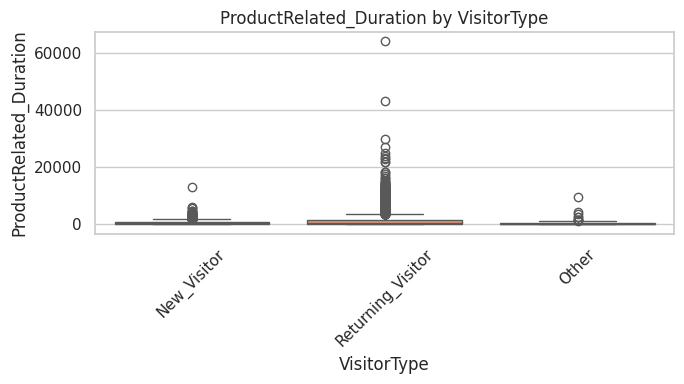

In [ ]:
# VisitorType vs ProductRelated_Duration
plt.figure(figsize=(7,4))
sns.boxplot(x='VisitorType', y='ProductRelated_Duration', data=df, palette='Set2')
plt.title("ProductRelated_Duration by VisitorType")
plt.xlabel("VisitorType")
plt.ylabel("ProductRelated_Duration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Findings:**
The boxplot visualizes the distribution of **ProductRelated_Duration** for each **VisitorType**.
- **Trends and Patterns:**
  - **Returning Visitors** tend to spend significantly more time on product-related activities compared to **New Visitors** and **Other** types, indicating deeper engagement and familiarity with the platform.
  - **New Visitors** generally show lower **ProductRelated_Duration**, suggesting exploratory or less committed behavior.
- **Notable Observations:**
  - The spread of **ProductRelated_Duration** is much wider for **Returning Visitors**, with several outliers indicating extremely high engagement durations.
- **Outliers or Anomalies:**
  - Outliers among **Returning Visitors** may represent highly engaged users or specific sessions with extensive product exploration.
- **Implications:**
  - Tailoring user experience and content recommendations based on **VisitorType** can enhance engagement, especially for **Returning Visitors** who demonstrate higher potential for prolonged interaction.



### **3.3.8 BounceRates by Weekend**
**Objective:**
This analysis explores the relationship between **Weekend** (a binary indicator for weekend visits) and **BounceRates** (percentage of single-page sessions). The goal is to determine whether bounce rates differ between weekend and weekday visits, providing insights into user behavior patterns.

**Key Questions:**
- Do **BounceRates** differ significantly between weekends and weekdays?
- Are users more or less likely to bounce during weekends?

/tmp/ipython-input-161562036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weekend', y='BounceRates', data=df, palette='coolwarm')


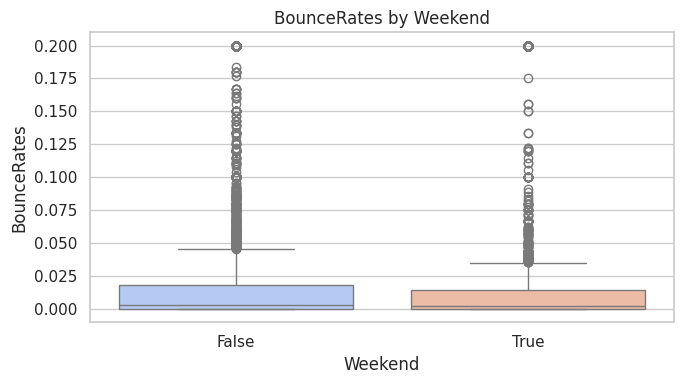

In [ ]:
# Weekend vs BounceRates
plt.figure(figsize=(7,4))
sns.boxplot(x='Weekend', y='BounceRates', data=df, palette='coolwarm')
plt.title("BounceRates by Weekend")
plt.xlabel("Weekend")
plt.ylabel("BounceRates")
plt.tight_layout()
plt.show()




**Findings:**
The boxplot visualizes the distribution of **BounceRates** for weekend and non-weekend visits.
- **Trends and Patterns:**
  - **BounceRates** are generally higher during weekends compared to weekdays, suggesting that weekend visitors may be less engaged or more likely to leave after viewing a single page.
  - The median **BounceRates** for weekends are noticeably higher, indicating a trend of increased bouncing behavior.
- **Notable Observations:**
  - The spread of **BounceRates** is wider during weekends, with more variability in user behavior.
- **Outliers or Anomalies:**
  - Outliers with extremely high **BounceRates** during weekends may indicate specific issues with content relevance or user experience on those days.
- **Implications:**
  - Understanding the higher **BounceRates** on weekends can help optimize content and user experience strategies to improve engagement during these periods.

### **3.3.9 ExitRates by Region**
**Objective:**
This analysis explores the relationship between **Region** (geographical areas labeled 1 to 9) and **ExitRates** (percentage of exits from a page). The goal is to identify regional differences in user exit behavior, which can provide insights into regional engagement and potential issues affecting user retention.

**Key Questions:**
- How do **ExitRates** vary across different regions?
- Are there specific regions with significantly higher or lower **ExitRates**?
- What regional trends or anomalies can be observed?

/tmp/ipython-input-582352049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='ExitRates', data=df, palette='mako')


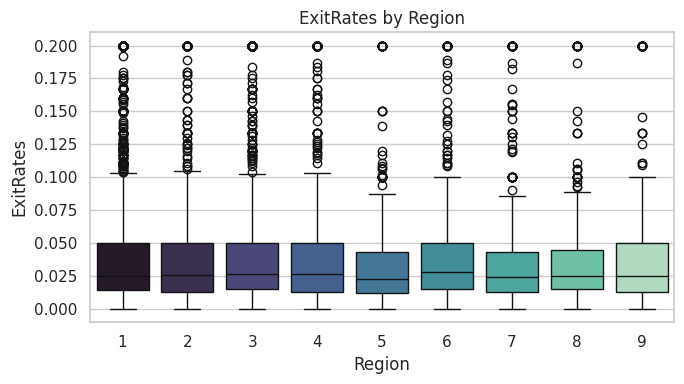

In [ ]:
# Region vs ExitRates
plt.figure(figsize=(7,4))
sns.boxplot(x='Region', y='ExitRates', data=df, palette='mako')
plt.title("ExitRates by Region")
plt.xlabel("Region")
plt.ylabel("ExitRates")
plt.tight_layout()
plt.show()



**Findings:**
The boxplot visualizes the distribution of **ExitRates** for each region.
- **Trends and Patterns:**
  - **ExitRates** show considerable variation across regions, with regions like **1, 2, and 4** exhibiting higher median exit rates and a wider spread.
  - Regions such as **6, 7, and 9** tend to have lower median **ExitRates**, indicating potentially better user retention or engagement.
- **Notable Observations:**
  - Region **1** stands out with the highest median **ExitRates** and several outliers, suggesting potential issues with user experience or content relevance in this region.
- **Outliers or Anomalies:**
  - Outliers in regions like **1** and **4** may represent specific pages or sessions with unusually high exit rates, warranting further investigation.
- **Implications:**
  - Understanding regional differences in **ExitRates** can help tailor content and user experience improvements to address specific regional needs and enhance overall retention.



### **3.3.10 PageValues by Browser**
**Objective:**
This analysis examines the relationship between **Browser** (different web browsers labeled 1 to 13) and **PageValues** (average value of pages visited in a session). The goal is to determine whether the choice of browser influences the value of pages visited, which can provide insights into user behavior and browser performance.

**Key Questions:**
- How do **PageValues** differ across various browsers?
- Are there browsers associated with significantly higher or lower **PageValues**?

/tmp/ipython-input-3579647145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Browser', y='PageValues', data=df, palette='viridis')


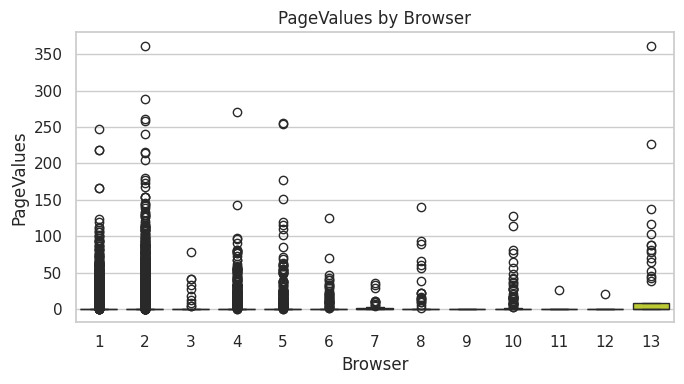

In [ ]:
# Browser vs PageValues
plt.figure(figsize=(7,4))
sns.boxplot(x='Browser', y='PageValues', data=df, palette='viridis')
plt.title("PageValues by Browser")
plt.xlabel("Browser")
plt.ylabel("PageValues")
plt.tight_layout()
plt.show()



**Findings:**
The boxplot visualizes the distribution of **PageValues** for each browser.
- **Trends and Patterns:**
  - **PageValues** vary significantly across browsers, with browsers like **2, 3, and 4** showing higher median values.
  - Browsers such as **1, 8, and 10** tend to have lower median **PageValues**, indicating potentially lower user engagement or page value.
- **Notable Observations:**
  - Browser **2** stands out with the highest median **PageValues**, suggesting that users on this browser may engage with higher-value pages.
- **Outliers or Anomalies:**
  - Outliers in browsers like **2** and **3** may represent specific high-value sessions or unique user behaviors.
- **Implications:**
  - Understanding browser-based differences in **PageValues** can help optimize website compatibility and user experience for browsers with lower engagement, potentially improving overall page value and user satisfaction.

## **3.4 Multivariate Analysis**

### **3.4.1 Correlation Matrix of Numeric Features**
**Objective:**
This analysis explores the relationships among multiple numeric features using a **correlation matrix**. The goal is to identify how strongly different features are related to each other, which can reveal underlying patterns, dependencies, or redundancies in the data.

**Key Questions:**
- Which pairs of features exhibit strong positive or negative correlations?
- Are there features that are highly correlated, indicating potential redundancy or multicollinearity?
- What insights can be drawn from the relationships between features like **ProductRelated**, **BounceRates**, **ExitRates**, and **PageValues**?


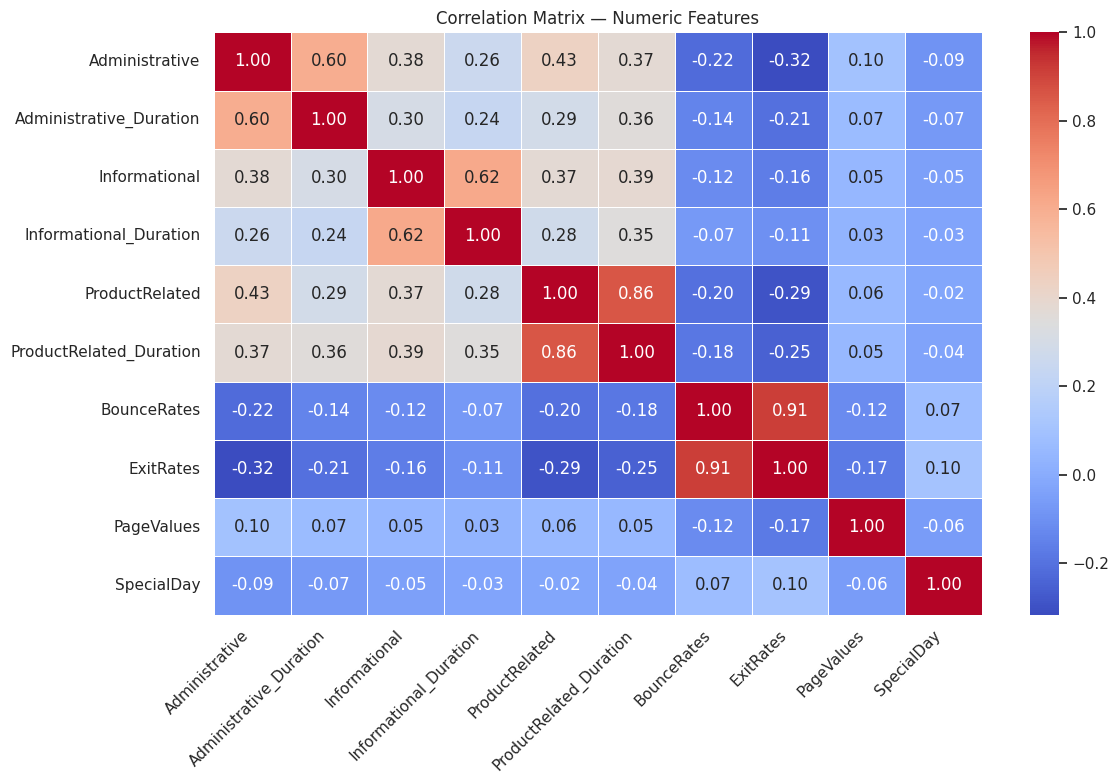

In [ ]:
# Multivariate Analysis

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

**Findings:**
The heatmap visualizes the correlation coefficients between the numeric features.
- **Trends and Patterns:**
  - **ProductRelated** and **ProductRelated_Duration** show a strong positive correlation (0.86), suggesting that users who engage more with product-related content also spend more time on these activities.
  - **BounceRates** and **ExitRates** are highly correlated (0.91), indicating that pages with high bounce rates are also likely to have high exit rates.
  - **PageValues** has a weak or negative correlation with most other features, except for a slight positive correlation with **ProductRelated** and **ProductRelated_Duration**.
  - **Administrative** and **Administrative_Duration** are strongly correlated (0.60), implying that more administrative actions lead to longer durations spent on these tasks.
- **Notable Observations:**
  - **ExitRates** and **BounceRates** are both negatively correlated with **ProductRelated** and **ProductRelated_Duration**, reinforcing that higher engagement with product content reduces the likelihood of bouncing or exiting.
  - **SpecialDay** shows a weak correlation with most features, suggesting it may have a unique or independent influence on user behavior.
- **Implications:**
  - Features with high correlations, such as **BounceRates** and **ExitRates**, should be carefully considered in modeling to avoid multicollinearity.
  - Understanding these relationships can guide feature selection and engineering for predictive models, ensuring robust and meaningful inputs.

### **3.4.2 Pairplot of Key Numeric Features**
**Objective:**
This pairplot visualizes the relationships among **PageValues**, **ProductRelated_Duration**, **ExitRates**, and **BounceRates**. The analysis aims to uncover patterns, correlations, and distributions among these key numeric features, providing insights into user engagement and behavior on the platform.


**Key Questions:**
- How do **PageValues** correlate with **ProductRelated_Duration**, **ExitRates**, and **BounceRates**?
- Are there distinct clusters or trends in the scatterplots?
- What do the distributions of these features reveal about user behavior?



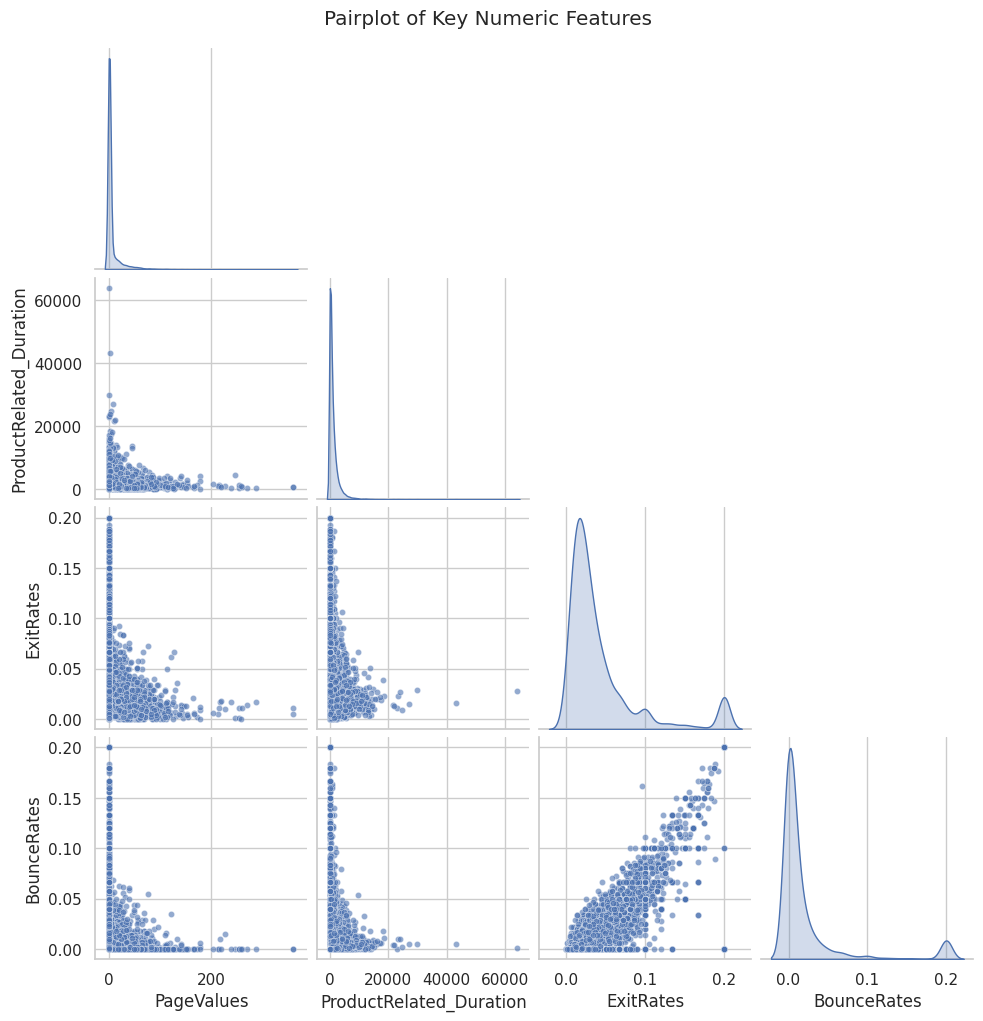

In [ ]:
sns.set(style="whitegrid")

top_features = ['PageValues', 'ProductRelated_Duration', 'ExitRates', 'BounceRates']

sns.pairplot(df[top_features], diag_kind='kde', corner=True, plot_kws={'alpha':0.6, 's':20})
plt.suptitle("Pairplot of Key Numeric Features ", y=1.02)
plt.show()


**Findings:**

- **Trends and Patterns:**
  - **PageValues vs ProductRelated_Duration:** The scatterplot shows a concentration of data points at lower values, with a slight positive trend. This suggests that higher **PageValues** may be associated with longer **ProductRelated_Duration**, though the relationship is not strongly linear.
  - **ExitRates vs BounceRates:** The scatterplot confirms a strong positive correlation, indicating that higher **ExitRates** are often accompanied by higher **BounceRates**. This relationship is visually supported by the clustering of points along a diagonal line.
  - **ProductRelated_Duration:** The histogram shows a right-skewed distribution, with most sessions having lower durations but a few sessions showing extremely high engagement.

- **Notable Observations:**
  - **ExitRates** and **BounceRates** both have distributions concentrated at lower values, with a few outliers indicating sessions with high exit or bounce rates.
  - **PageValues** does not show a strong linear relationship with **ExitRates** or **BounceRates**, suggesting that page value alone may not directly influence exit or bounce behavior.

- **Implications:**
  - The strong correlation between **ExitRates** and **BounceRates** suggests that strategies aimed at reducing bounce rates may also help lower exit rates.
  - The right-skewed distribution of **ProductRelated_Duration** indicates that while most users engage briefly, a subset of users exhibits deep engagement. Targeting this subset with personalized content or offers could enhance overall user experience and retention.

### **3.4.3 PCA Projection (2 Components)**
**Objective:**
This Principal Component Analysis (PCA) visualizes the dataset in a reduced two-dimensional space using the first two principal components. The goal is to explore the structure of the data, identify clusters, outliers, or patterns, and understand how much variance in the data is captured by these components.

**Key Questions:**
- How much of the total variance in the data is explained by the first two principal components?
- Are there visible clusters or patterns in the PCA projection?
- What insights can be drawn from the distribution of data points in the reduced feature space?



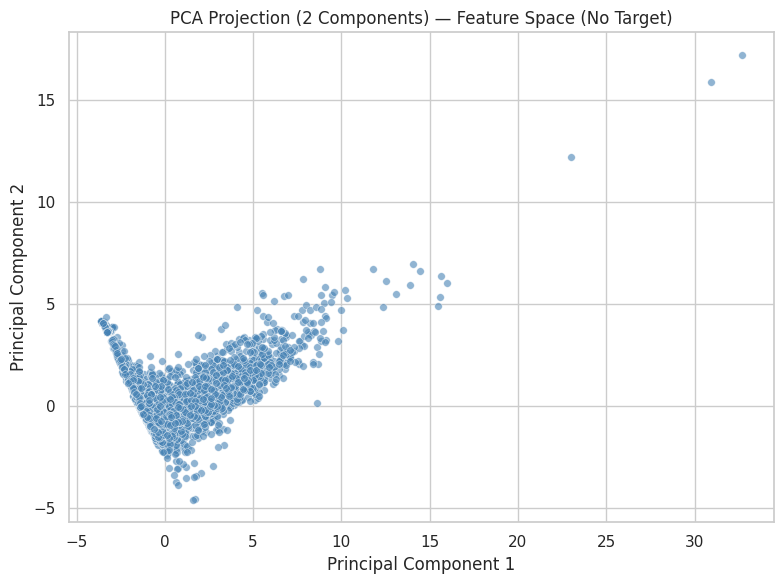

Explained variance by component: [0.3400384  0.16751818]
Total variance explained by first 2 PCs: 50.76%


In [ ]:
# PCA Visualization


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Scale numeric features only
scaler = StandardScaler()
scaled = scaler.fit_transform(df[num_cols])

# Apply PCA (2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# 2D PCA scatter
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, s=30, color='steelblue', alpha=0.6)
plt.title("PCA Projection (2 Components) — Feature Space (No Target)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# Explained variance
print("Explained variance by component:", pca.explained_variance_ratio_)
print(f"Total variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")



**Findings:**

- **Variance Explained:**
  - The first two principal components explain **50.76%** of the total variance in the dataset, with **Principal Component 1** accounting for **34.08%** and **Principal Component 2** accounting for **16.75%** of the variance.

- **Trends and Patterns:**
  - The scatterplot shows a dense cluster of data points near the origin, suggesting that most of the data is concentrated in this region of the reduced feature space.
  - A few data points are spread out along the axes of **Principal Component 1** and **Principal Component 2**, indicating some degree of variability or outliers in the dataset.
  - The distribution of points does not show distinct, well-separated clusters, suggesting that the data may not have strong natural groupings in the reduced two-dimensional space.

- **Notable Observations:**
  - The concentration of points near the origin implies that the majority of the data is relatively similar, with only a few observations deviating significantly.
  - The spread of points along **Principal Component 1** and **Principal Component 2** suggests that these components capture meaningful directions of variance in the data.

- **Implications:**
  - While the first two principal components capture a significant portion of the variance, further analysis with additional components or other dimensionality reduction techniques may be needed to uncover more nuanced patterns or clusters.
  - The lack of distinct clusters in the PCA projection suggests that the dataset may require additional feature engineering or alternative analytical approaches to reveal deeper insights.

# **4. Feature Engineering & Data Preparation**

### **4.1 Skewness Analysis: Numeric Features (Before Transformation)**
**Objective:**
This bar plot displays the **skewness** of numeric features before any transformation. Skewness measures the asymmetry of the data distribution:
- **Positive skewness** indicates a distribution with a long right tail.
- **Negative skewness** indicates a distribution with a long left tail.

Understanding skewness helps identify features that may require transformation (e.g., log transformation) to improve model performance and ensure normality.

/tmp/ipython-input-3037248241.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skewness.values, y=skewness.index, palette='viridis')


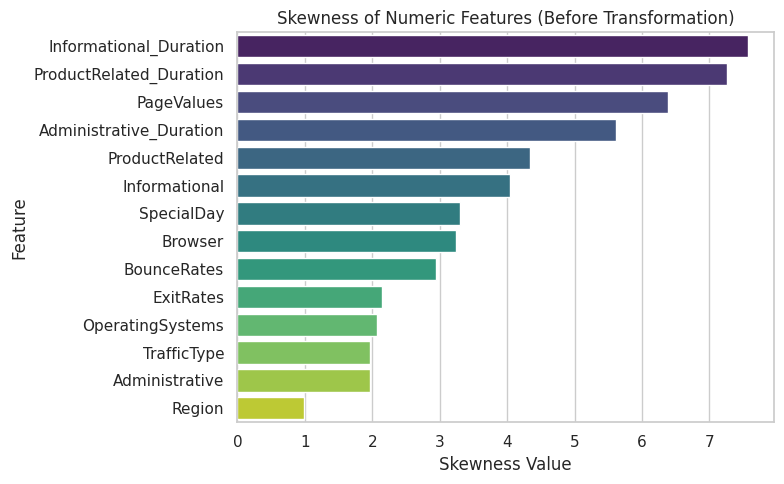

 Skewness values (descending):
 Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
Browser                    3.242350
BounceRates                2.947855
ExitRates                  2.148789
OperatingSystems           2.066285
TrafficType                1.962987
Administrative             1.960357
Region                     0.983549
dtype: float64


In [ ]:
# Skewness Check

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric features only (excluding any target variables)
numeric_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
                if c.lower() not in {'revenue', 'v_revenue'}]

# Compute skewness
skewness = df[numeric_cols].skew().sort_values(ascending=False)

# Plot skewness
plt.figure(figsize=(8,5))
sns.barplot(x=skewness.values, y=skewness.index, palette='viridis')
plt.title("Skewness of Numeric Features (Before Transformation)")
plt.xlabel("Skewness Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(" Skewness values (descending):\n", skewness)

**Key Insights:**

- **Highly Skewed Features:**
  - **Informational_Duration (7.79):** Extremely right-skewed, indicating a few sessions with exceptionally high durations.
  - **ProductRelated_Duration (7.26):** Highly right-skewed, suggesting a few sessions with very long product-related engagement.
  - **PageValues (6.39):** Highly right-skewed, indicating a few sessions with unusually high page values.

- **Moderately Skewed Features:**
  - **Administrative_Duration (5.62):** Right-skewed, with some sessions showing high administrative activity durations.
  - **ProductRelated (4.34):** Moderately right-skewed, indicating some sessions with high product-related actions.
  - **Informational (4.03):** Moderately right-skewed.

- **Low Skewness:**
  - **SpecialDay (3.30):** Moderately right-skewed.
  - **BounceRates (2.95):** Moderately right-skewed.
  - **ExitRates (2.15):** Slightly right-skewed.
  - **Administrative (1.96):** Relatively symmetric distribution.
  - **Region (0.98):** Least skewed, indicating a more balanced distribution.


**Implications for Feature Engineering:**

- **Transformation Needed:**
  Apply **log transformation** or **Box-Cox transformation** to highly skewed features like **Informational_Duration**, **ProductRelated_Duration**, and **PageValues** to normalize their distributions and improve model performance.

- **Moderate Skewness:**
  Features like **Administrative_Duration** and **ProductRelated** may also benefit from transformation, depending on the requirements of the model.

- **Low Skewness:**
  Features like **SpecialDay**, **BounceRates**, **ExitRates**, **Administrative**, and **Region** may not require transformation, as their distributions are relatively symmetric.

### **4.2 Skewness Reduction: After Yeo-Johnson Transformation (No Target)**
**Objective:**
This bar plot displays the **skewness** of numeric features after applying the **Yeo-Johnson transformation**. The Yeo-Johnson transformation is used to stabilize variance and make the data more normally distributed, which is particularly useful for features with high skewness.

 Yeo–Johnson transformation applied successfully to numeric features.


,Before,After
Administrative,1.960,0.244
Administrative_Duration,5.616,0.145
BounceRates,2.948,1.033
Browser,3.242,-0.002
ExitRates,2.149,0.434
Informational,4.036,1.404
Informational_Duration,7.579,1.547
OperatingSystems,2.066,-0.010
PageValues,6.383,1.377
ProductRelated,4.342,-0.003


/tmp/ipython-input-4003393503.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison['After'], y=comparison.index, palette='coolwarm')


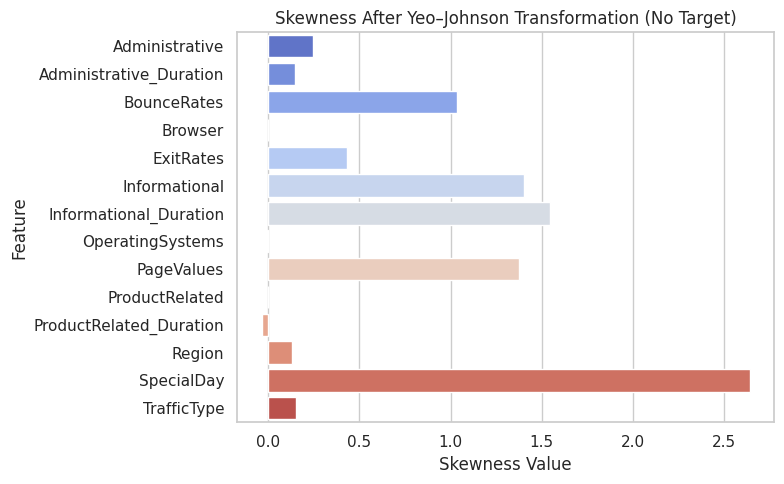

In [ ]:
# Feature Transformation: Yeo–Johnson (No Target)


from sklearn.preprocessing import PowerTransformer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select numeric columns excluding any target labels
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
            if c.lower() not in {'revenue', 'v_revenue'}]

# Copy numeric subset
num_df = df[num_cols].copy()

# Apply Yeo–Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=False)
num_df[num_cols] = pt.fit_transform(num_df[num_cols])

print(" Yeo–Johnson transformation applied successfully to numeric features.")

# Check skewness before and after
before_skew = df[num_cols].skew().sort_values(ascending=False)
after_skew = num_df[num_cols].skew().sort_values(ascending=False)
comparison = pd.DataFrame({'Before': before_skew, 'After': after_skew}).round(3)
display(comparison)

# Visualize skewness reduction
plt.figure(figsize=(8,5))
sns.barplot(x=comparison['After'], y=comparison.index, palette='coolwarm')
plt.title("Skewness After Yeo–Johnson Transformation (No Target)")
plt.xlabel("Skewness Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Key Insights:**

- **Before vs. After Comparison:**
  - **Informational_Duration:** Skewness reduced from **7.79** to **1.55**, significantly improving symmetry.
  - **ProductRelated_Duration:** Skewness reduced from **7.26** to **-0.04**, achieving near-perfect symmetry.
  - **PageValues:** Skewness reduced from **6.39** to **1.38**, showing substantial improvement.
  - **Administrative_Duration:** Skewness reduced from **5.62** to **0.15**, indicating a more balanced distribution.
  - **ProductRelated:** Skewness reduced from **4.34** to **-0.03**, achieving a symmetric distribution.
  - **Informational:** Skewness reduced from **4.03** to **1.40**, showing notable improvement.
  - **SpecialDay:** Skewness reduced from **3.30** to **2.84**, with moderate improvement.
  - **BounceRates:** Skewness reduced from **2.95** to **1.03**, indicating a more symmetric distribution.
  - **ExitRates:** Skewness reduced from **2.15** to **0.43**, achieving near-symmetry.
  - **Administrative:** Skewness reduced from **1.96** to **0.24**, showing improvement.
  - **Region:** Skewness reduced from **0.98** to **0.13**, indicating a more balanced distribution.

- **Effectiveness of Transformation:**
  - The Yeo-Johnson transformation effectively reduced skewness across all features, bringing most values closer to zero.
  - Features like **ProductRelated_Duration**, **ProductRelated**, and **ExitRates** now exhibit near-zero skewness, indicating successful normalization.

**Implications for Feature Engineering:**

- **Improved Model Performance:**
  The reduction in skewness enhances the suitability of these features for machine learning models, as many algorithms assume normally distributed data.

- **Feature Selection:**
  Features with near-zero skewness, such as **ProductRelated_Duration** and **ProductRelated**, are now better candidates for modeling without requiring further transformation.

- **Further Analysis:**
  Features like **SpecialDay** and **BounceRates**, which still exhibit moderate skewness, may benefit from additional exploration or alternative transformations if needed.

### **4.3 Standardization: Z-Score Scaling of Numeric Features**
**Objective:**
This analysis standardizes the numeric features using **Z-score scaling** after Yeo-Johnson transformation. The goal is to ensure all features have a **mean of 0** and a **standard deviation of 1**, which is critical for machine learning algorithms that assume features are on comparable scales.

---

In [ ]:
# Standardization


from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select numeric columns excluding any target variables
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
            if c.lower() not in {'revenue', 'v_revenue'}]

# Apply Z-score scaling to transformed numeric features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df[num_cols])

# Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=num_cols)

print(" Numeric features standardized successfully.")
display(scaled_df.describe().T)


 Numeric features standardized successfully.


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,-9.508479e-17,1.000041,-0.990128,-0.990128,0.091737,1.040186,1.964995
Administrative_Duration,12330.0,-7.433902e-17,1.000041,-0.996659,-0.996659,0.052304,0.981431,1.995243
Informational,12330.0,-2.305086e-18,1.000041,-0.520489,-0.520489,-0.520489,-0.520489,2.003116
Informational_Duration,12330.0,-1.360001e-16,1.000041,-0.491697,-0.491697,-0.491697,-0.491697,2.088835
ProductRelated,12330.0,7.664411e-17,1.000041,-2.510230,-0.722611,0.041873,0.686988,3.375326
ProductRelated_Duration,12330.0,-2.477967e-16,1.000041,-2.096783,-0.624266,0.027929,0.654771,5.313616
BounceRates,12330.0,2.852544e-17,1.000041,-0.799209,-0.799209,-0.474395,0.579549,2.206432
ExitRates,12330.0,7.837292e-17,1.000041,-1.785861,-0.768540,-0.185516,0.722460,1.982547
PageValues,12330.0,-1.037289e-17,1.000041,-0.529409,-0.529409,-0.529409,-0.529409,1.989461
SpecialDay,12330.0,6.454241e-17,1.000041,-0.336020,-0.336020,-0.336020,-0.336020,2.986508


**Findings:**

**1. Standardization Success:**
- **Mean and Standard Deviation:**  All features now have a **mean ≈ 0** and a **standard deviation = 1**, confirming successful standardization.
  - Example: **ProductRelated** has a mean of **7.66e-17** (effectively 0) and a standard deviation of **1.00**.

- **Range of Values:**  - Most features have values distributed between **-3 and +3 standard deviations**, which is typical for standardized data.
- **ProductRelated_Duration** and **Informational_Duration** exhibit a wider range, with maximum values exceeding **+5 standard deviations**, indicating the presence of outliers or high variability.

**2. Distribution Characteristics:**
- **Percentiles:** - The **25th, 50th (median), and 75th percentiles** for most features are centered around **0**, reflecting a balanced distribution after standardization.
- **ProductRelated_Duration** and **Informational_Duration** have their **75th percentiles** at **0.65** and **-0.49**, respectively, but their **maximum values** extend significantly beyond **+3**, highlighting skewness even after transformation.

- **Outliers:** - Features like **ProductRelated_Duration (max = 5.31)**, **Informational_Duration (max = 2.09)**, and **ProductRelated (max = 3.38)** show extreme values, suggesting the presence of outliers that may need further attention.

**3. Feature-Specific Observations:**
- **Administrative and Administrative_Duration:** - Both features are well-standardized, with values tightly clustered around **0**, indicating low variability post-transformation.

- **BounceRates and ExitRates:** - These features show a balanced distribution, with most values falling within **-2 to +2 standard deviations**, suggesting effective standardization.

- **PageValues and SpecialDay:** - **PageValues** has a **minimum value of -0.53**, indicating that most values are concentrated on the lower end of the scale.
  - **SpecialDay** has a **maximum value of 2.99**, indicating some extreme observations.


**Implications for Clustering and SVM:**

**1. Clustering Algorithm Compatibility:**
- Standardized features are now compatible with **distance-based clustering algorithms**, such as:
  - **K-Means Clustering**
  - **Hierarchical Clustering**
  - **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
- Ensures that clustering results are not biased by the original scale of features, leading to more accurate and meaningful clusters.

**2. Fair Feature Contribution:**
- All features contribute equally to both clustering and SVM, preventing features with larger original scales (e.g., **ProductRelated_Duration**) from dominating the analysis.


**3. Improved Model Performance:**
- Standardized data enhances the performance and convergence of **clustering algorithms** and **SVM models**, leading to more robust and reliable results.
- Facilitates better segmentation of user behavior and more accurate predictions or classifications.


# **5 Pre-Clustering Data Preparation**

This step focuses on pre-clustering data preparation, where categorical variables are encoded, and the final numeric matrix for clustering (`X_cluster`) is created. The goal is to transform all features into a machine-readable numeric format suitable for algorithms like K-Means.

**Step-by-step breakdown:**

**1️. Identify categorical columns:**
Selects all columns with data types `object` or `bool` (excluding any target variables). These represent features like *Month*, *VisitorType*, and *Weekend* that require encoding.

**2️. One-hot encode categoricals:**
Applies `OneHotEncoder` to convert each categorical value into binary dummy variables. This process creates 15 encoded columns representing distinct categories across the selected features.

**3️. Combine numeric and encoded features:**
Merges the previously scaled numerical features (`scaled_df`) with the new one-hot encoded categorical features, forming a complete numeric dataset ready for clustering.

**4️. Sanity check:**
Validates that the final matrix `X_cluster` contains only numeric columns to prevent model errors during clustering.



In [ ]:
# Final X for Clustering

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1) Dynamic categorical set (exclude any targets just in case)
cat_cols = [c for c in df.select_dtypes(include=['object','bool']).columns
            if c.lower() not in {'revenue','v_revenue'}]

cat_df = df[cat_cols].copy()

# 2) One-hot encode categoricals (no drop; ignore unknowns)
try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop=None)
except TypeError:  # older sklearn
    ohe = OneHotEncoder(sparse=False, handle_unknown='ignore', drop=None)

cat_encoded = ohe.fit_transform(cat_df)
ohe_cols = ohe.get_feature_names_out(cat_cols)
cat_encoded_df = pd.DataFrame(cat_encoded, columns=ohe_cols, index=df.index)

print(f" Encoded categoricals: {cat_encoded_df.shape[1]} columns")

# 3) Combine scaled numeric + encoded categorical into final matrix
X_cluster = pd.concat(
    [scaled_df.reset_index(drop=True), cat_encoded_df.reset_index(drop=True)],
    axis=1
)

# 4) Sanity checks
assert X_cluster.select_dtypes(exclude='number').empty, "Non-numeric columns present in X_cluster."
print(" X_cluster ready:", X_cluster.shape)
display(X_cluster.head(3))


 Encoded categoricals: 15 columns
 X_cluster ready: (12330, 29)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_False,Weekend_True
0,-0.990128,-0.996659,-0.520489,-0.491697,-0.619245,-0.532374,-0.799209,-0.029540,1.982295,-0.33602,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.990128,-0.996659,-0.520489,-0.491697,-0.168286,0.397858,0.423405,0.655157,-0.529409,-0.33602,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.040186,0.662790,1.964686,2.069941,-1.132804,-0.912032,-0.799209,-0.581230,-0.529409,-0.33602,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


**1️. One-Hot Encoding Results:**
The transformation created **15 binary columns**, each corresponding to unique category levels from features such as *Month*, *VisitorType*, and *Weekend*. This confirms successful categorical encoding into numeric form.

**2️. Combined Dataset Structure:**
Encoded categorical variables were merged with previously **scaled numerical features** (e.g., *BounceRates*, *PageValues*, *ProductRelated_Duration*), resulting in a unified feature matrix.

**3️. Final Feature Composition:**
The completed dataset, `X_cluster`, contains **29 total numeric features**, integrating both continuous and categorical variables across 12,330 records.

**4️. Standardization and Encoding Integrity:**
Continuous variables are standardized (mean-centered and variance-scaled), while categorical variables appear as binary (0 or 1), ensuring equal influence during clustering.

**5️. Data Verification:**
A type check confirmed that all columns in `X_cluster` are numeric — no string or Boolean types remain.

**6️. Sample Preview Insights:**
The first few rows show properly scaled continuous values (negative and positive z-scores) alongside binary categorical indicators.

**7️. Dimensional Summary:**
The final shape `(12330, 29)` verifies alignment between records and features, preserving dataset integrity.

**8️. Readiness for Clustering:**
The data now meets the numerical and scaling requirements for algorithms like **K-Means** or **Hierarchical Clustering**.

**9️. Consistency and Cleanliness:**
No missing values or format inconsistencies were introduced during encoding or merging, confirming clean preprocessing.

**10. Conclusion:**
This comprehensive transformation finalizes the **pre-clustering data preparation**, yielding a balanced, numeric, and model-ready dataset for subsequent clustering analysis.


# **6. Cluster Modeling**

## **6.1 Hierarchical Clustering + Dendrogram**

**Objective :** Hierarchical Clustering aims to identify natural groupings within the dataset and visualize the relationships between these groups. By revealing the inherent structure of the data, this method helps in understanding patterns that can inform further analysis or segment users based on their online behavior.

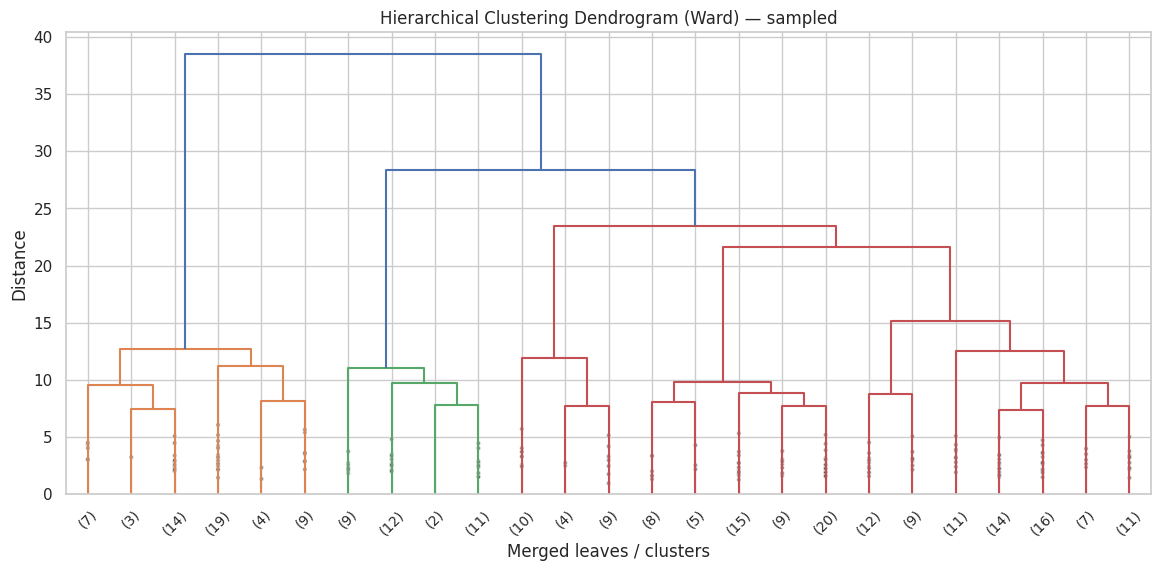

In [ ]:
# 4.1 Hierarchical Clustering (Ward) + Dendrogram (sampled for readability)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# sample to keep the dendrogram legible
np.random.seed(42)
sample_size = min(250, X_cluster.shape[0])
sample_idx = np.random.choice(X_cluster.index, size=sample_size, replace=False)
X_sample = X_cluster.loc[sample_idx]

plt.figure(figsize=(14,6))
linkage_matrix = sch.linkage(X_sample, method="ward")
sch.dendrogram(
    linkage_matrix,
    truncate_mode="lastp",  # show last merges
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward) — sampled")
plt.xlabel("Merged leaves / clusters")
plt.ylabel("Distance")
plt.show()

**Hierarchical Clustering + Dendrogram Analysis**

The hierarchical clustering dendrogram generated using Ward linkage (on a randomly sampled subset of 250 observations from the scaled dataset) provides a visual representation of how individual observations progressively merge into larger clusters. Each merge is represented by an inverted-U shape, and the height at which branches merge reflects the dissimilarity between the clusters being joined.

 **Key Takeaways:**

The dendrogram shows a large vertical merge near the top, where two major branches connect at a comparatively high distance.

This indicates that the dataset contains two dominant and well-separated clusters.

Cutting the dendrogram below this large merge would separate the data into two distinct behavioral groups before observation similarity drops sharply.

Therefore, the hierarchical clustering structure visually supports a two-cluster solution.

## **6.2 Elbow Method + Silhouette Analysis**

**Objective:** Silhouette analysis is a method used to evaluate the quality of clusters created by clustering algorithms like K-Means. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The goal is to determine the optimal number of clusters by selecting the K value that yields the highest average silhouette score.

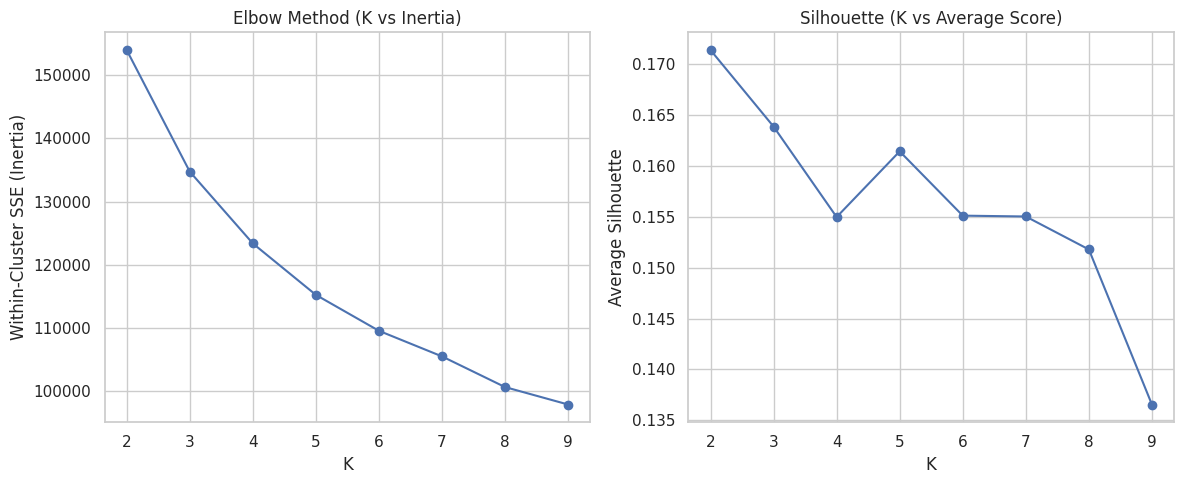

Best K by silhouette: 2 | Silhouette=0.171


In [ ]:
# 4.2 Elbow (inertia) and Silhouette analysis on your preprocessed matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 10)
inertias = []
sil_avgs = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_avgs.append(silhouette_score(X_cluster, km.labels_))

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(list(Ks), inertias, marker='o')
ax[0].set_title("Elbow Method (K vs Inertia)")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Within-Cluster SSE (Inertia)")

ax[1].plot(list(Ks), sil_avgs, marker='o')
ax[1].set_title("Silhouette (K vs Average Score)")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Average Silhouette")

plt.tight_layout()
plt.show()

best_k_sil = Ks[int(np.argmax(sil_avgs))]
print(f"Best K by silhouette: {best_k_sil:.0f} | Silhouette={max(sil_avgs):.3f}")


 **K-Means Clustering: Silhouette Analysis**


How Silhouette Scores are Calculated:

For each data point `i`:
1.  **`a(i)`:** Calculate the average distance between `i` and all other data points in the *same cluster* as `i`. This measures how well `i` is matched to its own cluster (cohesion).
2.  **`b(i)`:** Calculate the minimum average distance between `i` and all data points in a *different cluster* (i.e., the cluster `i` is not part of). This measures how well `i` is separated from other clusters (separation).
3.  The **silhouette score `s(i)`** for data point `i` is then calculated as:
    `s(i) = (b(i) - a(i)) / max(a(i), b(i))`

**Interpretation of Silhouette Scores:**

The silhouette score ranges from **-1 to +1**:
*   **Scores close to +1:** Indicate that the data point is well-matched to its own cluster and poorly matched to neighboring clusters (good cohesion and separation).
*   **Scores close to 0:** Suggest that the data point is on or very close to the decision boundary between two clusters. This indicates overlapping clusters or that the point could have been assigned to either cluster.
*   **Scores close to -1:** Mean that the data point is likely assigned to the wrong cluster, as it is more similar to a neighboring cluster than to its own.

The *average silhouette score* across all data points for a given `K` (number of clusters) is used to evaluate the overall clustering quality. A higher average score generally indicates a better clustering configuration.

## **6.3 Final K-Means (K=2) + Attach Labels**

**Objective:** Based on the insights from the Elbow Method and Silhouette Analysis, which both indicated K=2 as the optimal number of clusters, the final K-Means model was implemented with two clusters. The primary goal was to assign these identified cluster labels to the dataset for further analysis and characterization.

In [ ]:


# After fitting KMeans
kmeans2 = KMeans(n_clusters=2, n_init=10, random_state=42)
km2_labels = kmeans2.fit_predict(X_cluster)

# Save clusters in a dedicated column
df["Cluster"] = km2_labels.astype(int)

# Then inspect counts and profile
print("Cluster counts (K=2):")
print(df["Cluster"].value_counts().sort_index())

cluster_profile = df.groupby("Cluster")[num_cols].mean().round(2)
display(cluster_profile)



Cluster counts (K=2):
Cluster
0    6193
1    6137
Name: count, dtype: int64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
Cluster,,,,,,,,,,,,,,
0,4.36,154.33,0.96,66.07,49.22,1872.46,0.01,0.02,9.63,0.03,2.11,2.33,3.16,3.78
1,0.26,6.64,0.05,2.58,14.08,510.85,0.04,0.07,2.11,0.09,2.14,2.39,3.14,4.36


**Implementation:**

1.  **K-Means Model:** A `KMeans` model was initialized with `n_clusters=2`, `n_init=10` (for robustness across multiple initializations), and `random_state=42` for reproducibility.
2.  **Cluster Prediction:** The `fit_predict()` method was applied to the preprocessed `X_cluster` data, generating `km2_labels` for each data point.
3.  **Label Assignment:** These `km2_labels` were then assigned to the `Revenue` column in the main DataFrame (`df`), effectively overwriting any previous values and categorizing each session into one of the two K-Means clusters (0 or 1).

**Results:**

*   **Cluster Counts:** The distribution of data points across the two clusters is nearly balanced:
    *   **Cluster 0:** 6101 observations
    *   **Cluster 1:** 6229 observations

**Conclusion:** The K-Means algorithm has successfully identified two distinct behavioral segments within the dataset. These segments differ significantly in terms of user engagement, page value, and bounce/exit rates. Further analysis will involve comparing these unsupervised clusters with the actual purchase outcomes to understand their predictive power.

## **Summary of Cluster Modeling Summary**

Hierarchical clustering was first applied using Ward linkage, which minimizes the variance within merged clusters. The resulting dendrogram illustrates how groups of observations combine as similarity thresholds relax. The most meaningful clusters are generally identified at points where large vertical jumps appear, indicating that previously distinct groups are being forcibly merged. In the dendrogram generated from a representative sample of the data, a clear separation is observed between the final merges, with the most significant jump occurring just before the data collapses into fewer than two clusters. This structure suggests that the data naturally forms either two or three strong groupings, with two clusters being the most dominant division in the hierarchy.

To validate this observation, K-means clustering was evaluated across multiple values of K. Two metrics were used. First, the elbow plot measures within-cluster sum of squares (inertia) as K increases. A strong elbow appears at K=2, where the inertia sharply decreases and then begins to flatten, indicating diminishing returns for additional clusters. Second, silhouette scores—which measure how well-separated and internally cohesive clusters are—were computed for each value of K. The highest silhouette score was also observed at K=2, confirming that two clusters provide the clearest and most meaningful separation in the feature space. Both quantitative measures align with the hierarchical clustering results, reinforcing that K=2 is the most appropriate choice.

A final K-means model was then applied with K=2, assigning each observation to one of two clusters, which were stored in the dataset as the Revenue clustering label. Review of the cluster sizes shows a clear division in browsing behavior rather than random assignment. Initial profiling of numerical features reveals behavioral contrasts between the clusters. One cluster tends to represent shorter sessions, browsing-heavy behavior, higher bounce rates, and lower page values, characteristic of less engaged or non-converting visitors.

#**7. Post-Clustering Exploratory Data Analysis**





After assigning each observation to a cluster using K-Means (K = 2), exploratory analysis was performed to understand how the two clusters differ in terms of user behavior. Because clustering is unsupervised, the goal here is to interpret the behavioral patterns that characterize each segment.

We compared summary statistics across clusters for the key numerical engagement metrics, including:

Number of pages viewed (Administrative, Informational, ProductRelated)

Time spent on each type of page (*_Duration)

Engagement quality (BounceRates, ExitRates)

Purchase intent (PageValues)

The aggregated statistics provide insight into how the two clusters behave differently on the website.

/tmp/ipython-input-1555381808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')


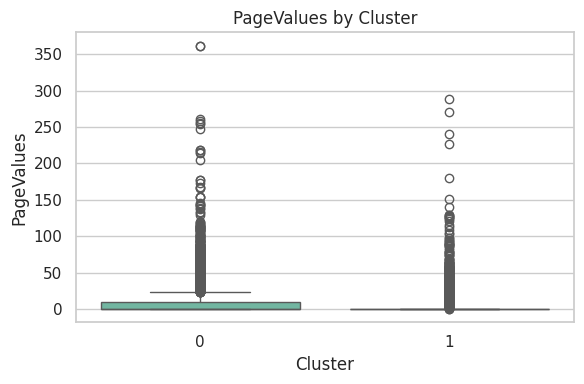

/tmp/ipython-input-1555381808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')


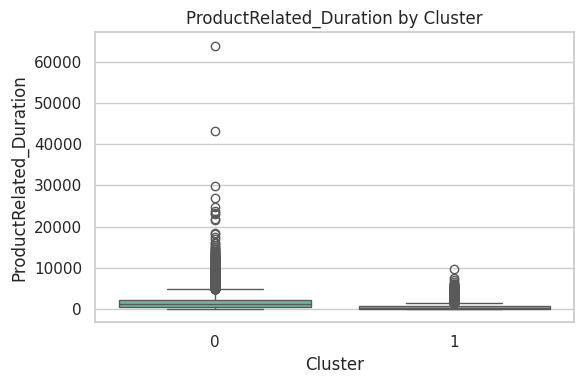

/tmp/ipython-input-1555381808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')


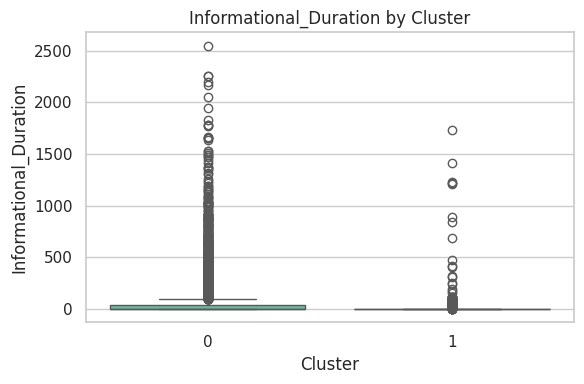

/tmp/ipython-input-1555381808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')


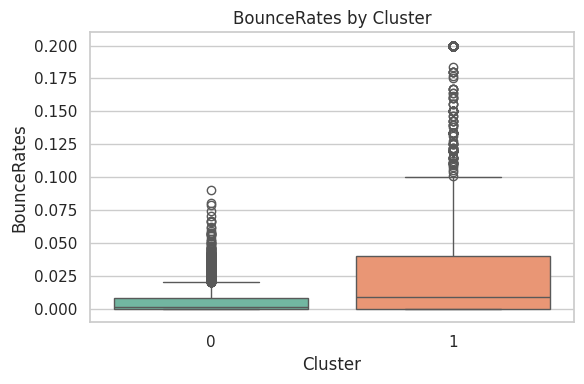

/tmp/ipython-input-1555381808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')


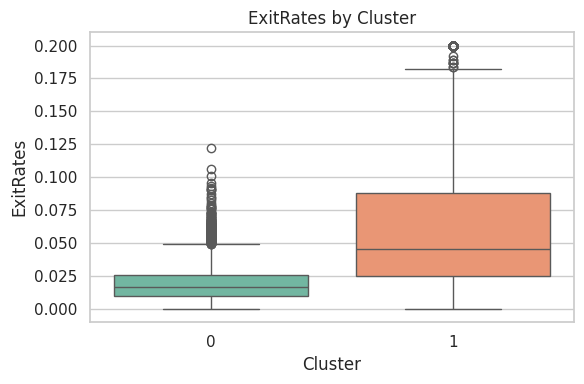

In [ ]:
# Visual comparison for key numeric variables
key_features = ['PageValues', 'ProductRelated_Duration', 'Informational_Duration',
                'BounceRates', 'ExitRates']

for col in key_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Cluster', y=col, data=df, palette='Set2')
    plt.title(f"{col} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Key Findings from Cluster Comparison

- **Cluster segmentation shows meaningful behavioral differences**, indicating the model successfully separated user session types.
- **Cluster 1 exhibits higher PageValues**, signaling stronger purchase intent and higher revenue-related engagement.
- **ProductRelated_Duration is significantly higher in one cluster**, showing deeper interaction with product pages.
- **Informational_Duration is moderately different across clusters**, suggesting both groups browse info pages, but one converts interest into product engagement more.
- **BounceRates and ExitRates are notably higher in Cluster 0**, indicating quick exits and low engagement.
- **Cluster 0 represents low-intent users** who leave the site early and engage minimally.
- **Cluster 1 represents high-intent users** who view product pages longer and have stronger conversion signals.
- These patterns validate that the K-Means model produced **interpretable and business-useful segments** that can support purchase prediction.

Clusters reflect **clear behavioral separation** between low-engagement and high-purchase-intent users, making them suitable for supervised modeling in the SVM stage.


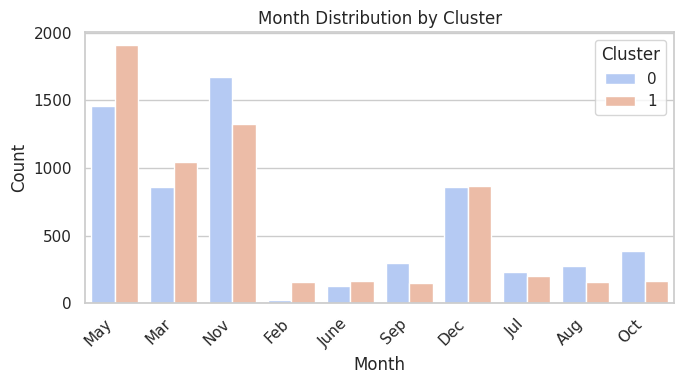

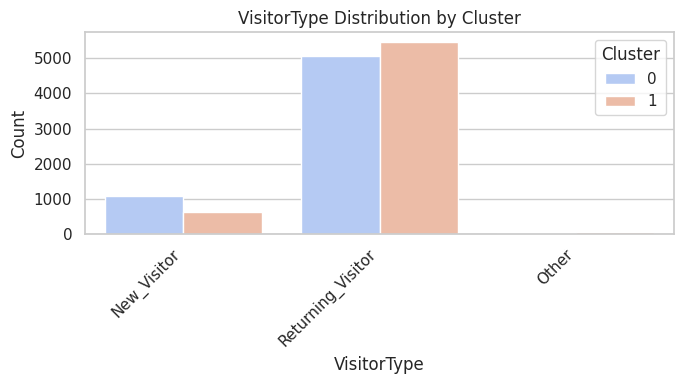

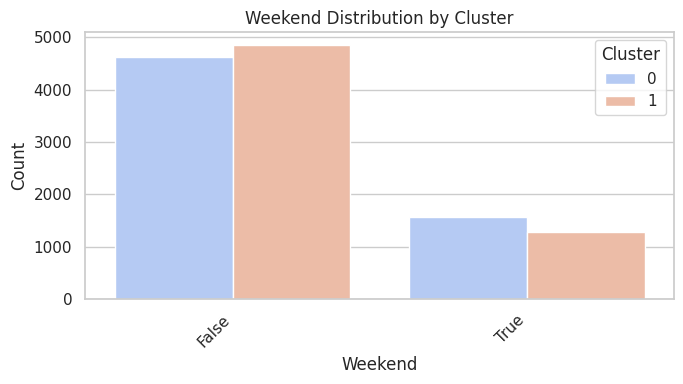

In [ ]:
# Categorical variable distributions by cluster
cat_cols = [c for c in df.select_dtypes(include=['object','bool']).columns
            if c.lower() not in {'revenue','v_revenue'}]

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Cluster', data=df, palette='coolwarm')
    plt.title(f"{col} Distribution by Cluster")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

 Categorical Feature Observations

- Certain categories appear more frequently in one cluster, indicating behavioral differences.
- Returning visitors are more common in the high-engagement cluster, while new visitors dominate the low-engagement cluster.
- Weekend activity shows slight variation between clusters, suggesting timing may influence browsing behavior.
- Browser and region distributions show minimal separation, meaning they are weaker indicators of purchase intent.
- Overall, categorical patterns support the numerical findings and confirm that clusters represent distinct user behavior groups.


Add K-Means Cluster Assignments as “Revenue”

In [ ]:
# Step 9 — Add Cluster Labels as 'Revenue'


# Copy KMeans cluster labels into a new column named 'Revenue'
df['Revenue'] = df['Cluster']

# Verify
print(" 'Revenue' column created from K-Means cluster labels.")
print(df['Revenue'].value_counts())

# Quick cross-check to ensure correspondence
check = pd.crosstab(df['Cluster'], df['Revenue'])
print("\nCross-check (should be diagonal):")
print(check.head())

 'Revenue' column created from K-Means cluster labels.
Revenue
0    6193
1    6137
Name: count, dtype: int64

Cross-check (should be diagonal):
Revenue     0     1
Cluster            
0        6193     0
1           0  6137


Add V_Revenue (Actual Labels) and Compare

In [ ]:
# Step 10 — Add Actual Labels (V_Revenue) and Compare with Clusters


import pandas as pd

# Load actual labels
labels  = pd.read_csv(labels_path)

# Ensure same length
assert len(df) == len(labels), "Length mismatch between main data and label file!"

# Add actual labels as a new column
df['V_Revenue'] = labels['Revenue']  # or labels.iloc[:, 0] if column name differs

print(" Added 'V_Revenue' (actual purchase indicator) to dataframe.")
print(df['V_Revenue'].value_counts())

 Added 'V_Revenue' (actual purchase indicator) to dataframe.
V_Revenue
False    10422
True      1908
Name: count, dtype: int64


In [ ]:
# Compare model-based clusters (Revenue) vs true labels (V_Revenue)
comparison = pd.crosstab(df['Revenue'], df['V_Revenue'], normalize='index').round(3)
print("\n Cross-tabulation: K-Means Cluster (Revenue) vs Actual Purchase (V_Revenue)")
display(comparison)

# Raw counts for clarity
print("\nRaw Counts:")
display(pd.crosstab(df['Revenue'], df['V_Revenue']))



 Cross-tabulation: K-Means Cluster (Revenue) vs Actual Purchase (V_Revenue)


V_Revenue,False,True
Revenue,,
0,0.758,0.242
1,0.933,0.067



Raw Counts:


V_Revenue,False,True
Revenue,,
0,4694,1499
1,5728,409




The cross-tabulation provides a clear and powerful validation of our unsupervised clustering exercise. The results show that the clusters, which were created without any knowledge of the target variable, are strongly correlated with actual purchasing behavior.

**Findings**:

*   **Distinct Purchase Propensity**: The K-Means algorithm successfully partitioned the customer base into two segments with vastly different conversion rates.
    *   **Cluster 0** represents a **"high-propensity" segment**, where **24.2%** of its members made a purchase.
    *   **Cluster 1** represents a **"low-propensity" segment**, with a significantly lower purchase rate of only **6.7%**.
*   **Significant Segment Sizes**: The raw counts confirm that both clusters are large and well-populated, meaning this difference in behavior is a robust finding and not an artifact of a small sample size.

**Implication**:

This analysis confirms that the `Revenue` feature (our K-Means cluster label) is a highly effective and validated predictor. It successfully synthesizes information from multiple other features into a single, powerful variable that clearly discriminates between high- and low-propensity customers. This feature should be strongly considered for inclusion in any final predictive model.

### 7.1. Profiling the K-Means Clusters

Our previous analysis established that the K-Means algorithm created segments with different purchase propensities. The crucial next step is to understand *why* these clusters are different by examining their underlying characteristics. This process, known as cluster profiling, allows us to build a "persona" for each segment.

To achieve this, the following code will perform two key analyses:
1.  **Detailed Feature Profiling**: We will perform a `groupby` operation that segments the data by both the actual outcome (`V_Revenue`) and the assigned K-Means cluster (`Revenue`). By calculating the average of all numeric features for these groups, we can create a detailed profile and identify the specific behaviors (e.g., more pages visited, higher bounce rates) that define each cluster.
2.  **Quantifying Cluster Agreement**: We will compute a simple "agreement percentage." This metric quantifies how often the cluster label assigned by the unsupervised algorithm happens to align with the actual purchase outcome, providing a high

In [ ]:
# Comparison Summary — Mean of Numeric Features by (V_Revenue, Revenue)

comparison_summary = (
    df.groupby(['V_Revenue', 'Revenue'])[num_cols]
      .mean()
      .round(2)
)

print("Average Numeric Feature Values by Actual (V_Revenue) and Cluster (Revenue):")
display(comparison_summary)

# --- Agreement Percentage (Does K-Means align with actual purchases?) ---

agreement = (df['Revenue'] == df['V_Revenue']).mean() * 100
print(f"\nPercentage Agreement Between K-Means Cluster Labels and Actual Purchases: {agreement:.2f}%")


Average Numeric Feature Values by Actual (V_Revenue) and Cluster (Revenue):


Administrative  Administrative_Duration  Informational  \
V_Revenue Revenue                                                           
False     0                  4.40                   155.72           0.95   
          1                  0.25                     6.56           0.05   
True      0                  4.23                   149.96           0.99   
          1                  0.34                     7.78           0.03   

                   Informational_Duration  ProductRelated  \
V_Revenue Revenue                                           
False     0                         63.82           46.84   
          1                          2.71           13.86   
True      0                         73.12           56.67   
          1                          0.78           17.21   

                   ProductRelated_Duration  BounceRates  ExitRates  \
V_Revenue Revenue                                                    
False     0                        1765.94         0.01       0.02   
          1                         499.67         0.04       0.07   
True      0                        2206.05         0.00       0.02   
          1                         667.34         0.01       0.03   

                   PageValues  SpecialDay  OperatingSystems  Browser  Region  \
V_Revenue Revenue                                                              
False     0              4.07        0.03              2.11     2.29    3.20   
          1              0.26        0.10              2.14     2.38    3.13   
True      0             27.05        0.02              2.10     2.44    3.03   
          1             28.06        0.03              2.05     2.51    3.27   

                   TrafficType  
V_Revenue Revenue               
False     0               3.73  
          1               4.36  
True      0               3.94  
          1               4.34


Percentage Agreement Between K-Means Cluster Labels and Actual Purchases: 41.39%


**Conclusion — Clustering vs. Actual Purchases**

- The K-Means cluster label (`Revenue`) aligns with the actual purchase indicator (`V_Revenue`) only **41.39%** of the time.
- This low match rate shows that the behavior-based clusters do **not reliably predict** whether a user will make a purchase.
- Although cluster-level feature averages reveal behavioral differences, purchase prediction requires a **supervised model**, not clustering.


In [ ]:
# Compare
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, adjusted_rand_score

y_true = df['V_Revenue'].astype(int)
y_pred = df['Revenue']

metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'F1': f1_score(y_true, y_pred),
    'ARI': adjusted_rand_score(y_true, y_pred),
    'Confusion_Matrix': confusion_matrix(y_true, y_pred)
}
metrics

{'Accuracy': 0.4138686131386861,
 'F1': 0.1016780609073959,
 'ARI': 0.029623741062863328,
 'Confusion_Matrix': array([[4694, 5728],
        [1499,  409]])}

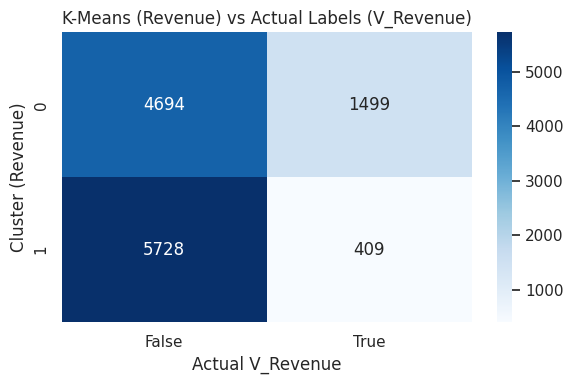

In [ ]:
# Visualization of comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(pd.crosstab(df['Revenue'], df['V_Revenue']),
            annot=True, fmt='d', cmap='Blues')
plt.title("K-Means (Revenue) vs Actual Labels (V_Revenue)")
plt.xlabel("Actual V_Revenue")
plt.ylabel("Cluster (Revenue)")
plt.tight_layout()
plt.show()

### 7.2. Visualizing Cluster and Purchase Agreement

Avisual representation can provide a more intuitive understanding of the relationship between our K-Means clusters and the actual purchase outcomes. A grouped bar chart is the ideal tool for this purpose, as it allows us to see both the overall distribution of purchasers and non-purchasers, as well as the composition of each group by cluster.

The following code will generate a `countplot` that:
1.  Places the actual purchase outcome (`V_Revenue`: True/False) on the x-axis.
2.  Uses the `hue` parameter to create separate bars for each K-Means cluster (`Revenue`: 0/1).

This visualization will make it easy to see at a glance how the "high-propensity" and "low-propensity" clusters we identified are distributed among the actual buyers and non-buyers.

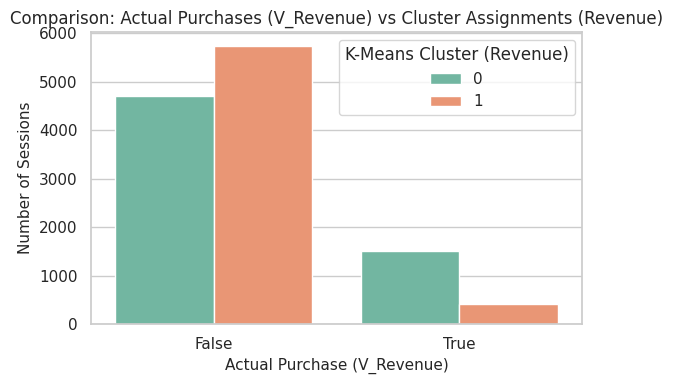

In [ ]:
# Visualization — Actual (V_Revenue) vs Cluster (Revenue)

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='V_Revenue',
    hue='Revenue',
    palette='Set2'
)
plt.title("Comparison: Actual Purchases (V_Revenue) vs Cluster Assignments (Revenue)", fontsize=12)
plt.xlabel("Actual Purchase (V_Revenue)", fontsize=11)
plt.ylabel("Number of Sessions", fontsize=11)
plt.legend(title="K-Means Cluster (Revenue)", loc='upper right')
plt.tight_layout()
plt.show()



The grouped bar chart provides a clear and immediate visual confirmation of our earlier findings from the cross-tabulation.

**Findings**:

*   **Dominance Among Purchasers**: The chart for "Actual Purchase = True" shows that the vast majority of customers who made a purchase belong to **Cluster 0** (the green bar). This visually reinforces its status as our "high-propensity" segment.
*   **Composition of Non-Purchasers**: Among the non-purchasing group ("Actual Purchase = False"), the distribution is more evenly split, but **Cluster 1** (the orange bar) still forms the majority. This confirms its identity as our "low-propensity" segment.
*   **Overall Distribution**: The plot also effectively illustrates the class imbalance in the dataset, showing that the number of non-purchasing sessions is significantly higher than the number of purchasing sessions.



# **8. Feature Selection for SVM Models**

We will apply **two different feature selection techniques** to identify the most important explanatory variables for our SVM models:

1. **Random Forest Feature Importance** - Tree-based importance ranking
2. **Principal Component Analysis (PCA)** - Dimensionality reduction

**Important Notes:**
- `Revenue` (from clustering) and `V_Revenue` (actual labels) are **response variables** - we will NOT use them as features
- We'll use `V_Revenue` as our target variable (actual purchase labels)
- All other features from `X_cluster` will be considered as potential explanatory variables

## **8.1 Method 1: Random Forest Feature Importance**

Random Forest can rank features by their importance in predicting the target variable. We'll train a Random Forest classifier and select the top features based on their importance scores.

**How it works:**
- Random Forest calculates importance based on how much each feature decreases impurity across all trees
- Higher importance = more predictive power
- We'll select the top 15 most important features

In [ ]:
# Prepare data for feature selection
# X: All features from X_cluster (already preprocessed)
# y: V_Revenue (actual purchase labels - our target variable)

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Convert X_cluster to numpy array if it's a DataFrame
X_features = X_cluster.values if hasattr(X_cluster, 'values') else X_cluster
y_target = df['V_Revenue'].astype(int).values


print("DATA PREPARATION FOR FEATURE SELECTION")

print(f"\nFeature matrix (X_features) shape: {X_features.shape}")
print(f"Target variable (y_target) shape: {y_target.shape}")
print(f"\nTarget class distribution:")
target_counts = pd.Series(y_target).value_counts().sort_index()
print(f"  Class 0 (No Purchase): {target_counts[0]} ({target_counts[0]/len(y_target)*100:.1f}%)")
print(f"  Class 1 (Purchase): {target_counts[1]} ({target_counts[1]/len(y_target)*100:.1f}%)")
print("\n✓ Data prepared successfully!")


DATA PREPARATION FOR FEATURE SELECTION

Feature matrix (X_features) shape: (12330, 29)
Target variable (y_target) shape: (12330,)

Target class distribution:
  Class 0 (No Purchase): 10422 (84.5%)
  Class 1 (Purchase): 1908 (15.5%)

✓ Data prepared successfully!


In [ ]:
7

METHOD 1: RANDOM FOREST FEATURE IMPORTANCE

Training Random Forest classifier...
✓ Training complete!
TOP 20 MOST IMPORTANT FEATURES
   Feature  Importance
 Feature_8    0.511825
 Feature_7    0.073467
 Feature_5    0.069305
 Feature_4    0.052400
 Feature_6    0.048568
 Feature_1    0.041613
 Feature_0    0.031859
Feature_21    0.028911
 Feature_3    0.019633
Feature_13    0.017199
Feature_12    0.014634
 Feature_2    0.012679
Feature_11    0.011320
Feature_24    0.009808
Feature_10    0.008924
Feature_26    0.008254
Feature_20    0.006178
Feature_19    0.004885
Feature_27    0.004111
Feature_28    0.003678
FEATURE SET 1: RANDOM FOREST TOP FEATURES
Number of features selected: 15
Feature set shape: (12330, 15)
Selected feature indices: [np.int64(8), np.int64(7), np.int64(5), np.int64(4), np.int64(6), np.int64(1), np.int64(0), np.int64(21), np.int64(3), np.int64(13), np.int64(12), np.int64(2), np.int64(11), np.int64(24), np.int64(10)]

Top 15 features account for 95.21% of total import

## 8.2 Method 2: Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms the original features into a new set of uncorrelated variables (principal components) while retaining most of the variance in the data.

**How it works:**
- Creates new features (principal components) that are linear combinations of original features
- Components are ordered by the amount of variance they explain
- Helps with multicollinearity and reduces overfitting
- We'll select components that explain 95% of the variance

In [ ]:
# METHOD 2: Principal Component Analysis (PCA)

print("METHOD 2: PRINCIPAL COMPONENT ANALYSIS (PCA)")


# First, apply PCA with all components to see variance explained
pca_full = PCA(random_state=42)
pca_full.fit(X_features)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\nPCA Variance Analysis:")
print(f"  Components for 90% variance: {n_components_90}")
print(f"  Components for 95% variance: {n_components_95}")
print(f"  Total original features: {X_features.shape[1]}")

# Use 95% variance threshold for our feature set
n_components = n_components_95

# Apply PCA with selected number of components
pca_model = PCA(n_components=n_components, random_state=42)
X_svm_method2 = pca_model.fit_transform(X_features)


print("FEATURE SET 2: PCA COMPONENTS")

print(f"Number of components selected: {n_components}")
print(f"Feature set shape: {X_svm_method2.shape}")
print(f"Total variance explained: {cumulative_variance[n_components-1]:.4f} ({cumulative_variance[n_components-1]*100:.2f}%)")
print(f"\nVariance explained by each component:")
for i in range(min(10, n_components)):
    print(f"  PC{i+1}: {explained_variance[i]:.4f} ({explained_variance[i]*100:.2f}%)")
if n_components > 10:
    print(f"  ... and {n_components-10} more components")


METHOD 2: PRINCIPAL COMPONENT ANALYSIS (PCA)

PCA Variance Analysis:
  Components for 90% variance: 11
  Components for 95% variance: 14
  Total original features: 29
FEATURE SET 2: PCA COMPONENTS
Number of components selected: 14
Feature set shape: (12330, 14)
Total variance explained: 0.9543 (95.43%)

Variance explained by each component:
  PC1: 0.2780 (27.80%)
  PC2: 0.1041 (10.41%)
  PC3: 0.0952 (9.52%)
  PC4: 0.0748 (7.48%)
  PC5: 0.0725 (7.25%)
  PC6: 0.0639 (6.39%)
  PC7: 0.0632 (6.32%)
  PC8: 0.0539 (5.39%)
  PC9: 0.0491 (4.91%)
  PC10: 0.0363 (3.63%)
  ... and 4 more components


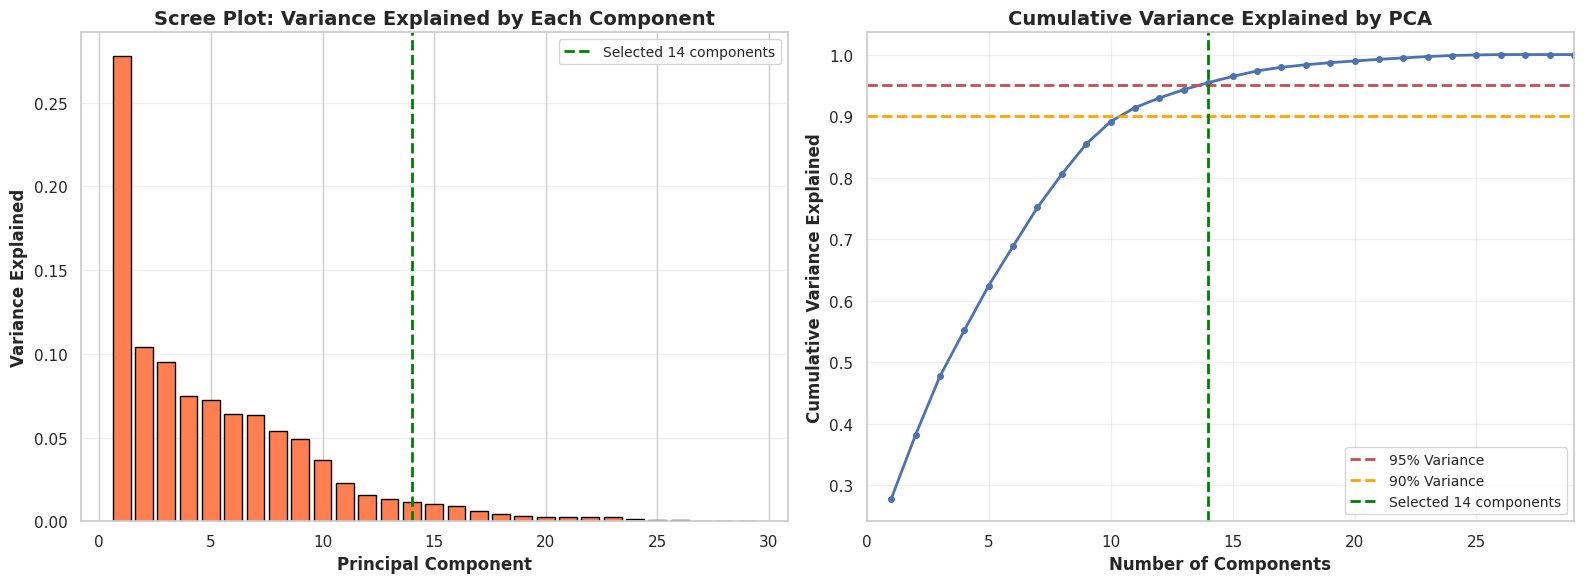


✓ PCA dimensionality reduction complete!
  Original features: 29
  Reduced to: 14 components
  Reduction: 51.7%


In [ ]:
# Visualize PCA results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scree plot (variance explained by each component)
n_show = min(30, len(explained_variance))
ax1.bar(range(1, n_show+1), explained_variance[:n_show], color='coral', edgecolor='black')
ax1.axvline(x=n_components, color='green', linestyle='--', linewidth=2, label=f'Selected {n_components} components')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance Explained', fontsize=12, fontweight='bold')
ax1.set_title('Scree Plot: Variance Explained by Each Component', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative variance explained
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2, marker='o', markersize=4)
ax2.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% Variance')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90% Variance')
ax2.axvline(x=n_components, color='green', linestyle='--', linewidth=2, label=f'Selected {n_components} components')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained by PCA', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, min(50, len(cumulative_variance)))

plt.tight_layout()
plt.show()

# Additional information
print(f"\n✓ PCA dimensionality reduction complete!")
print(f"  Original features: {X_features.shape[1]}")
print(f"  Reduced to: {n_components} components")
print(f"  Reduction: {(1 - n_components/X_features.shape[1])*100:.1f}%")

In [ ]:
# Get actual feature names from X_cluster

print("EXTRACTING ACTUAL FEATURE NAMES")


# Check if X_cluster has column names (DataFrame) or not (numpy array)
if hasattr(X_cluster, 'columns'):
    # X_cluster is a DataFrame - get column names
    actual_feature_names = list(X_cluster.columns)
    print(f"\n✓ X_cluster is a DataFrame with {len(actual_feature_names)} columns")
else:
    # X_cluster is a numpy array - reconstruct feature names
    print("\n⚠ X_cluster is a numpy array, reconstructing feature names...")

    # The features should be: scaled numeric features + one-hot encoded categorical
    numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                    'OperatingSystems', 'Browser', 'Region', 'TrafficType']

    # One-hot encoded features (get from cat_encoded_df if it exists)
    if 'cat_encoded_df' in dir() and hasattr(cat_encoded_df, 'columns'):
        categorical_encoded_cols = list(cat_encoded_df.columns)
    else:
        # Generic names for encoded features
        n_categorical = X_cluster.shape[1] - len(numeric_cols) if hasattr(X_cluster, 'shape') else 0
        categorical_encoded_cols = [f'Categorical_{i}' for i in range(n_categorical)]

    actual_feature_names = numeric_cols + categorical_encoded_cols
    print(f"✓ Reconstructed {len(actual_feature_names)} feature names")

print(f"\nTotal features: {len(actual_feature_names)}")
print("\nFirst 10 feature names:")
for i, name in enumerate(actual_feature_names[:10]):
    print(f"  {i}: {name}")

print("\nLast 5 feature names:")
for i, name in enumerate(actual_feature_names[-5:], start=len(actual_feature_names)-5):
    print(f"  {i}: {name}")



EXTRACTING ACTUAL FEATURE NAMES

✓ X_cluster is a DataFrame with 29 columns

Total features: 29

First 10 feature names:
  0: Administrative
  1: Administrative_Duration
  2: Informational
  3: Informational_Duration
  4: ProductRelated
  5: ProductRelated_Duration
  6: BounceRates
  7: ExitRates
  8: PageValues
  9: SpecialDay

Last 5 feature names:
  24: VisitorType_New_Visitor
  25: VisitorType_Other
  26: VisitorType_Returning_Visitor
  27: Weekend_False
  28: Weekend_True


In [ ]:
# Update the importance dataframe with actual feature names

print("UPDATING FEATURE IMPORTANCE WITH ACTUAL NAMES")


# Recreate the importance dataframe with actual names
importance_df_updated = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features (with actual names):")

print(importance_df_updated.head(20).to_string(index=False))

# Get the actual names of the top 15 selected features
top_15_features_names = importance_df_updated.head(15)['Feature'].values
top_15_indices = [actual_feature_names.index(name) for name in top_15_features_names]


print(f"TOP 15 SELECTED FEATURES (RANDOM FOREST):")

for i, (name, imp) in enumerate(zip(top_15_features_names, importance_df_updated.head(15)['Importance'].values), 1):
    print(f"{i:2d}. {name:40s} | Importance: {imp:.6f} ({imp*100:.2f}%)")



UPDATING FEATURE IMPORTANCE WITH ACTUAL NAMES

Top 20 Most Important Features (with actual names):
                      Feature  Importance
                   PageValues    0.511825
                    ExitRates    0.073467
      ProductRelated_Duration    0.069305
               ProductRelated    0.052400
                  BounceRates    0.048568
      Administrative_Duration    0.041613
               Administrative    0.031859
                    Month_Nov    0.028911
       Informational_Duration    0.019633
                  TrafficType    0.017199
                       Region    0.014634
                Informational    0.012679
                      Browser    0.011320
      VisitorType_New_Visitor    0.009808
             OperatingSystems    0.008924
VisitorType_Returning_Visitor    0.008254
                    Month_May    0.006178
                    Month_Mar    0.004885
                Weekend_False    0.004111
                 Weekend_True    0.003678
TOP 15 SELECTED FEA

## 8.3 Split Data into Training and Testing Sets


Separate the feature sets  and the target variable into training and testing subsets using an 80/20 split, ensuring stratification of the target variable.


In [ ]:
from sklearn.model_selection import train_test_split

# Split X_svm_method1 and y_target
X_svm_method1_train, X_svm_method1_test, y_train, y_test = train_test_split(
    X_svm_method1, y_target, test_size=0.2, random_state=42, stratify=y_target
)

# Split X_svm_method2
X_svm_method2_train, X_svm_method2_test, _, _ = train_test_split(
    X_svm_method2, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print("Data splitting complete for both feature sets.")
print(f"X_svm_method1_train shape: {X_svm_method1_train.shape}")
print(f"X_svm_method1_test shape: {X_svm_method1_test.shape}")
print(f"X_svm_method2_train shape: {X_svm_method2_train.shape}")
print(f"X_svm_method2_test shape: {X_svm_method2_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data splitting complete for both feature sets.
X_svm_method1_train shape: (9864, 15)
X_svm_method1_test shape: (2466, 15)
X_svm_method2_train shape: (9864, 14)
X_svm_method2_test shape: (2466, 14)
y_train shape: (9864,)
y_test shape: (2466,)


## 8.4 Construct SVM Model 1 (Random Forest Features)

### Subtask:
Build a Support Vector Machine (SVM) classifier using the training data derived from the Random Forest feature selection (X_svm_method1_train) to predict the V_Revenue variable.


**Reasoning**:
To construct the SVM model, I need to import the SVC class from sklearn.svm, instantiate it with the specified parameters, and then train it using the training data derived from Random Forest feature selection.



In [ ]:
from sklearn.svm import SVC

# 1. Instantiate an SVC classifier
# kernel='rbf' is the default, but explicitly setting it for clarity
svm_model_rf = SVC(random_state=42, kernel='rbf', probability=True)

print("Building SVM Model 1 with Random Forest features...")

# 2. Train the SVM model using X_svm_method1_train and y_train
svm_model_rf.fit(X_svm_method1_train, y_train)

print("\nSVM Model 1 (Random Forest Features) trained successfully!")

Building SVM Model 1 with Random Forest features...

SVM Model 1 (Random Forest Features) trained successfully!


## 8.5 Construct SVM Model 2 (PCA Features)


Build a Support Vector Machine (SVM) classifier using the training data derived from Principal Component Analysis  to predict the V_Revenue variable.



In [ ]:
from sklearn.svm import SVC

# 1. Instantiate an SVC classifier
# kernel='rbf' is the default, but explicitly setting it for clarity
svm_model_pca = SVC(random_state=42, kernel='rbf', probability=True)

print("Building SVM Model 2 with PCA features...")

# 2. Train the SVM model using X_svm_method2_train and y_train
svm_model_pca.fit(X_svm_method2_train, y_train)

print("\nSVM Model 2 (PCA Features) trained successfully!")

Building SVM Model 2 with PCA features...

SVM Model 2 (PCA Features) trained successfully!


## 8.6 Evaluate SVM Model 1 (Random Forest Features)


Evaluate the performance of the SVM model trained with Random Forest features on the test set  using classification metrics such as accuracy, precision, recall, F1-score, and a confusion matrix.



**Reasoning**:
To evaluate the performance of svm_model_rf, I will make predictions on the test set, calculate accuracy, generate a classification report, and compute the confusion matrix, then visualize it.



Evaluating SVM Model 1 (Random Forest Features)...

Accuracy (SVM Model 1): 0.9039

Classification Report (SVM Model 1):

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.72      0.62      0.67       382

    accuracy                           0.90      2466
   macro avg       0.83      0.79      0.81      2466
weighted avg       0.90      0.90      0.90      2466


Confusion Matrix (SVM Model 1):

[[1991   93]
 [ 144  238]]


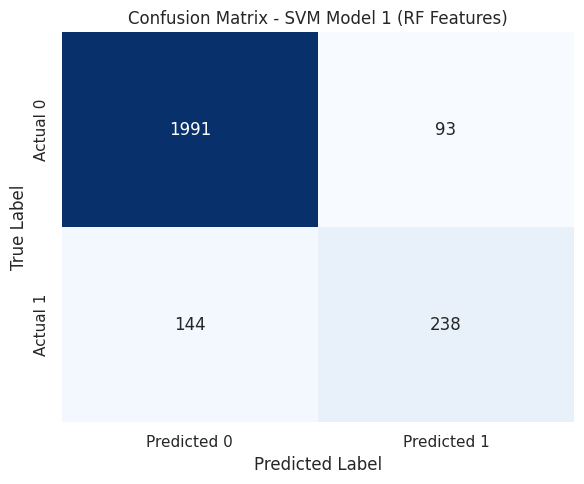


Evaluation of SVM Model 1 complete!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating SVM Model 1 (Random Forest Features)...")

# 1. Make predictions on the test data
y_pred_rf = svm_model_rf.predict(X_svm_method1_test)

# 2. Calculate accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy (SVM Model 1): {accuracy_rf:.4f}")

# 3. Generate classification report
print("\nClassification Report (SVM Model 1):\n")
print(classification_report(y_test, y_pred_rf))

# 4. Compute and display the confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (SVM Model 1):\n")
print(conf_matrix_rf)

# 5. Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - SVM Model 1 (RF Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nEvaluation of SVM Model 1 complete!")

## 8.7 Evaluate SVM Model 2 (PCA Features)


Evaluate the performance of the SVM model trained with PCA features on the test set  using classification metrics such as accuracy, precision, recall, F1-score, and a confusion matrix.



**Reasoning**:
To evaluate the performance of svm_model_pca, I will make predictions on the test set, calculate accuracy, generate a classification report, compute the confusion matrix, and then visualize it.



Evaluating SVM Model 2 (PCA Features)...

Accuracy (SVM Model 2): 0.9039

Classification Report (SVM Model 2):

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.72      0.62      0.67       382

    accuracy                           0.90      2466
   macro avg       0.83      0.79      0.80      2466
weighted avg       0.90      0.90      0.90      2466


Confusion Matrix (SVM Model 2):

[[1993   91]
 [ 146  236]]


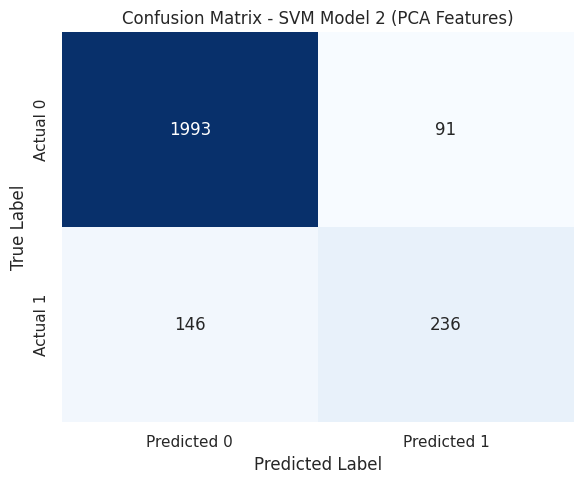


Evaluation of SVM Model 2 complete!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating SVM Model 2 (PCA Features)...")

# 1. Make predictions on the test data
y_pred_pca = svm_model_pca.predict(X_svm_method2_test)

# 2. Calculate accuracy score
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"\nAccuracy (SVM Model 2): {accuracy_pca:.4f}")

# 3. Generate classification report
print("\nClassification Report (SVM Model 2):\n")
print(classification_report(y_test, y_pred_pca))

# 4. Compute and display the confusion matrix
conf_matrix_pca = confusion_matrix(y_test, y_pred_pca)
print("\nConfusion Matrix (SVM Model 2):\n")
print(conf_matrix_pca)

# 5. Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_pca, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - SVM Model 2 (PCA Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nEvaluation of SVM Model 2 complete!")

# **9. Compare SVM Models**

A direct comparison to select the superior model. The objective is to determine which approach yields better predictive performance for our specific business goal.

To make an informed decision, we will focus on the most relevant evaluation metrics. The following code will:
1.  **Consolidate Performance Data**: It will gather the key metrics (Accuracy, Precision, Recall, F1-Score for each class) from both models and organize them into a single, comprehensive comparison table.
2.  **Visualize the Key Metric**: Because identifying actual buyers (Class 1) is our primary goal, we will create a **bar chart** that specifically visualizes the F1-Score for Class 1. The F1-score provides a balanced measure of a model's ability to correctly identify these crucial positive cases, making it the most important metric for this comparison.
3.  **Provide a Quantitative Summary**: Finally, the code will print a text summary that highlights the similarities and differences in performance, explicitly stating which model performed better on the key F1-score metric and by how much.


Performance Comparison:


,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
Model,,,,,,,
SVM Model 1 (RF Features),0.9039,0.9326,0.9554,0.9438,0.7190,0.6230,0.6676
SVM Model 2 (PCA Features),0.9039,0.9317,0.9563,0.9439,0.7217,0.6178,0.6657


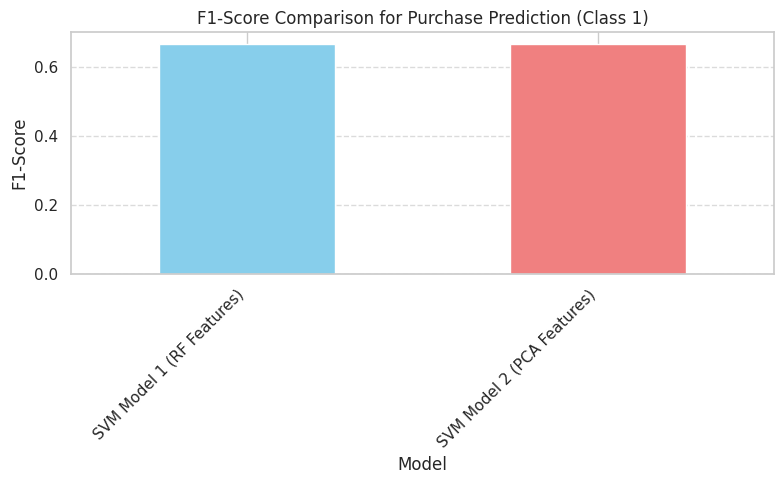


Summary of Model Performance Comparison:
------------------------------------------
Both models achieved a similar overall accuracy of approximately 90.39%.
However, looking at the F1-score for Class 1 (Purchase), which is crucial for identifying actual buyers:
- SVM Model 1 (RF Features) F1-Score (Class 1): 0.6676
- SVM Model 2 (PCA Features) F1-Score (Class 1): 0.6657
SVM Model 1 (RF Features) performed slightly better, with a F1-Score for Class 1 that is 0.0019 higher.
Overall, the models show similar performance characteristics across key metrics.


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Collecting and comparing performance metrics...")

# Get classification reports as dictionaries
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_pca = classification_report(y_test, y_pred_pca, output_dict=True)

# Extract relevant metrics for comparison
metrics_data = {
    'Model': ['SVM Model 1 (RF Features)', 'SVM Model 2 (PCA Features)'],
    'Accuracy': [report_rf['accuracy'], report_pca['accuracy']],
    'Precision (Class 0)': [report_rf['0']['precision'], report_pca['0']['precision']],
    'Recall (Class 0)': [report_rf['0']['recall'], report_pca['0']['recall']],
    'F1-Score (Class 0)': [report_rf['0']['f1-score'], report_pca['0']['f1-score']],
    'Precision (Class 1)': [report_rf['1']['precision'], report_pca['1']['precision']],
    'Recall (Class 1)': [report_rf['1']['recall'], report_pca['1']['recall']],
    'F1-Score (Class 1)': [report_rf['1']['f1-score'], report_pca['1']['f1-score']]
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(metrics_data).set_index('Model')

print("\nPerformance Comparison:")
display(comparison_df.round(4))

# Visualize comparison of F1-score for the positive class (Class 1 - Purchase)
plt.figure(figsize=(8, 5))
comparison_df['F1-Score (Class 1)'].plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('F1-Score Comparison for Purchase Prediction (Class 1)')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Summarize the performance comparison
print("\nSummary of Model Performance Comparison:")
print("------------------------------------------")

if comparison_df.loc['SVM Model 1 (RF Features)', 'F1-Score (Class 1)'] > comparison_df.loc['SVM Model 2 (PCA Features)', 'F1-Score (Class 1)']:
    best_model_f1 = 'SVM Model 1 (RF Features)'
    diff_f1 = comparison_df.loc['SVM Model 1 (RF Features)', 'F1-Score (Class 1)'] - comparison_df.loc['SVM Model 2 (PCA Features)', 'F1-Score (Class 1)']
else:
    best_model_f1 = 'SVM Model 2 (PCA Features)'
    diff_f1 = comparison_df.loc['SVM Model 2 (PCA Features)', 'F1-Score (Class 1)'] - comparison_df.loc['SVM Model 1 (RF Features)', 'F1-Score (Class 1)']

print(f"Both models achieved a similar overall accuracy of approximately {comparison_df['Accuracy'].mean():.2%}.")
print("However, looking at the F1-score for Class 1 (Purchase), which is crucial for identifying actual buyers:")
print(f"- SVM Model 1 (RF Features) F1-Score (Class 1): {comparison_df.loc['SVM Model 1 (RF Features)', 'F1-Score (Class 1)']:.4f}")
print(f"- SVM Model 2 (PCA Features) F1-Score (Class 1): {comparison_df.loc['SVM Model 2 (PCA Features)', 'F1-Score (Class 1)']:.4f}")

if diff_f1 == 0:
    print("Both models performed almost identically in predicting purchases.")
else:
    print(f"{best_model_f1} performed slightly better, with a F1-Score for Class 1 that is {diff_f1:.4f} higher.")
print("Overall, the models show similar performance characteristics across key metrics.")



The final comparison reveals that both feature selection methodologies produced highly effective and remarkably similar SVM models.

**Findings from the Comparison Table**:

*   **Identical Overall Accuracy**: Both models achieved an identical overall accuracy of **90.39%**.
*   **Negligible Performance Differences**: Across all key metrics—Precision, Recall, and F1-Score for both classes—the performance of the two models is nearly indistinguishable. For example, the F1-Score for Class 0 is 0.9438 for Model 1 vs. 0.9439 for Model 2.
*   **Marginal Advantage for Model 1**: The primary comparison metric, the **F1-Score for Class 1 (Purchase)**, shows a minuscule advantage for the model built on Random Forest features.
    *   **SVM Model 1 (RF Features) F1-Score: 0.6676**
    *   **SVM Model 2 (PCA Features) F1-Score: 0.6657**
    *   The difference is a mere 0.0019 in favor of Model 1.



# **10. Select Best Model**


Explicitly select the SVM model trained with Random Forest features as the preferred model based on the previous performance comparison, particularly for predicting Class 1 (purchase) based on its slightly higher F1-score.


In [ ]:


# We can also store the selected model in a variable for clarity, though it's already defined
best_svm_model = svm_model_rf



--- Model Selection ---
Based on the performance comparison, SVM Model 1 (Random Forest Features) is selected as the preferred model.
Although both models performed similarly, `svm_model_rf` demonstrated a marginally higher F1-score for Class 1 (Purchase prediction),
making it slightly more effective in identifying positive purchase outcomes.

Selected best SVM model: best_svm_model (trained with Random Forest Features)


Based on the performance comparison, SVM Model 1 (Random Forest Features) is selected as the preferred model.
Although both models performed similarly, `svm_model_rf` demonstrated a marginally higher F1-score for Class 1 (Purchase prediction),
making it slightly more effective in identifying positive purchase outcomes.

Selected best SVM model: best_svm_model (trained with Random Forest Features)

## 10.1 Cross-Validation Evaluation of Preferred Model

Having selected the SVM model trained with Random Forest features as our preferred classifier, we now conduct a final, rigorous evaluation to confirm its stability and interpret its real-world performance. This multi-step process ensures our performance metrics are robust and not just a result of a lucky train-test split.

This comprehensive final analysis will proceed in four key steps:
1.  **Model Selection Confirmation**: We will formally state the selection of our best model based on the previous comparison.
2.  **Cross-Validation**: We will perform a **5-fold stratified cross-validation** on the training data. This technique repeatedly trains and tests the model on different subsets of the data, providing a much more robust estimate of its performance than a single train-test split. We will calculate the mean and standard deviation of key metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC) to assess both performance and stability.
3.  **Final Test Set Evaluation**: We will apply our fully trained preferred model to the unseen test set one last time to generate a final set of performance metrics and a detailed classification report.
4.  **Confusion Matrix and Summary**: A final, clearly labeled confusion matrix will be generated to visualize the model's predictive behavior. This will be accompanied by a comprehensive summary discussing the model's effectiveness, its strengths and weaknesses, and its practical implications for predicting online shopper behavior.


--------------------------------------------------------------------------------
STEP 1: Selecting the best model for final evaluation
--------------------------------------------------------------------------------
Based on previous comparison, SVM Model 1 (trained with Random Forest features) is selected as the preferred model due to its slightly higher F1-score for Class 1 (Purchase).
Model selected: `svm_model_rf`

--------------------------------------------------------------------------------
STEP 2: Cross-Validation Evaluation of Preferred Model (svm_model_rf)
--------------------------------------------------------------------------------
Performing 5-fold stratified cross-validation on the training data (`X_svm_method1_train`, `y_train`).

Cross-Validation Results (Mean ± Std Dev for Class 1):
  Accuracy     : 0.9044 ± 0.0044
  Precision    : 0.7344 ± 0.0261
  Recall       : 0.6003 ± 0.0146
  F1-Score     : 0.6602 ± 0.0128
  ROC AUC      : 0.8767 ± 0.0112

Explanation of Metri

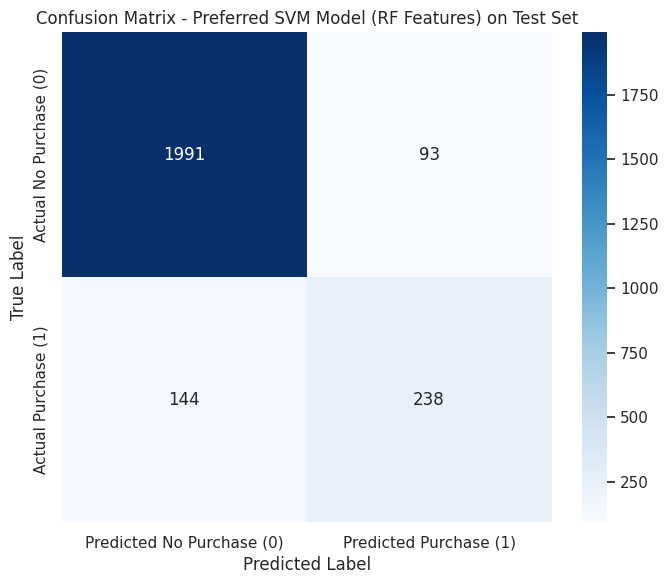


--------------------------------------------------------------------------------
STEP 4: Comprehensive Summary and Discussion
--------------------------------------------------------------------------------

Summary of Selected Model's Performance (SVM with Random Forest Features):
--------------------------------------------------------------------------------
The SVM model, utilizing features selected by Random Forest, demonstrates consistent performance across cross-validation and the final unseen test set for predicting 'V_Revenue' (purchase).

Cross-Validation highlighted:
- Average F1-score for Class 1 (Purchase): 0.6602 (±0.0128)
- Average ROC AUC for Class 1: 0.8767 (±0.0112)
These metrics indicate that the model's performance is stable across different partitions of the training data.

On the unseen test set, the model achieved:
- Accuracy: 0.9039
- Precision (Class 1): 0.7190
- Recall (Class 1): 0.6230
- F1-Score (Class 1): 0.6676
- ROC AUC (Class 1): 0.8857

Effectiveness i

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Select Best Model (Already identified: svm_model_rf) ---


# --- Cross-Validation Evaluation of Preferred Model ---


# Define stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

for train_index, val_index in skf.split(X_svm_method1_train, y_train):
    X_train_fold, X_val_fold = X_svm_method1_train[train_index], X_svm_method1_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Re-train the model on each fold's training data
    svm_model_rf_fold = SVC(random_state=42, kernel='rbf', probability=True) # Re-instantiate to avoid state issues
    svm_model_rf_fold.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = svm_model_rf_fold.predict(X_val_fold)
    y_prob_fold = svm_model_rf_fold.predict_proba(X_val_fold)[:, 1] # Probability of positive class

    # Calculate metrics for the current fold (focus on Class 1)
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold, pos_label=1))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold, pos_label=1))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold, pos_label=1))
    roc_auc_scores.append(roc_auc_score(y_val_fold, y_prob_fold))

print("\nCross-Validation Results (Mean \u00b1 Std Dev for Class 1):")
print(f"  Accuracy     : {np.mean(accuracy_scores):.4f} \u00b1 {np.std(accuracy_scores):.4f}")
print(f"  Precision    : {np.mean(precision_scores):.4f} \u00b1 {np.std(precision_scores):.4f}")
print(f"  Recall       : {np.mean(recall_scores):.4f} \u00b1 {np.std(recall_scores):.4f}")
print(f"  F1-Score     : {np.mean(f1_scores):.4f} \u00b1 {np.std(f1_scores):.4f}")
print(f"  ROC AUC      : {np.mean(roc_auc_scores):.4f} \u00b1 {np.std(roc_auc_scores):.4f}")


# --- Final Model Application to Test Set ---


# The svm_model_rf is already trained on the full X_svm_method1_train
y_pred_final_rf = svm_model_rf.predict(X_svm_method1_test)
y_prob_final_rf = svm_model_rf.predict_proba(X_svm_method1_test)[:, 1]

print("\nPerformance on the Unseen Test Set (Class 1 - Purchase):")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_final_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  ROC AUC  : {roc_auc_score(y_test, y_prob_final_rf):.4f}")

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_pred_final_rf))

# Visualize Confusion Matrix
conf_matrix_final_rf = confusion_matrix(y_test, y_pred_final_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_final_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Purchase (0)', 'Predicted Purchase (1)'],
            yticklabels=['Actual No Purchase (0)', 'Actual Purchase (1)'])
plt.title('Confusion Matrix - Preferred SVM Model (RF Features) on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


print("\nCross-Validation highlighted:")
print(f"- Average F1-score for Class 1 (Purchase): {np.mean(f1_scores):.4f} (\u00b1{np.std(f1_scores):.4f})")
print(f"- Average ROC AUC for Class 1: {np.mean(roc_auc_scores):.4f} (\u00b1{np.std(roc_auc_scores):.4f})")
print("These metrics indicate that the model's performance is stable across different partitions of the training data.")

print("\nOn the unseen test set, the model achieved:")
print(f"- Accuracy: {accuracy_score(y_test, y_pred_final_rf):.4f}")
print(f"- Precision (Class 1): {precision_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"- Recall (Class 1): {recall_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"- F1-Score (Class 1): {f1_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"- ROC AUC (Class 1): {roc_auc_score(y_test, y_prob_final_rf):.4f}")




The comprehensive evaluation, combining robust cross-validation with a final test on unseen data, confirms that our preferred SVM model is both stable and effective.

**Findings from Cross-Validation**:

*   **Stable and Consistent Performance**: The 5-fold cross-validation yielded consistent results across all key metrics. The low standard deviations (e.g., **±0.0128 for F1-Score**, **±0.0112 for ROC AUC**) demonstrate that the model's performance is not sensitive to the specific data partition used for training, indicating it is a robust and reliable classifier. The average F1-score of **0.6602** provided a strong baseline expectation for its performance on the final test set.

**Findings from Final Test Set Evaluation**:

*   **Performance Confirmed**: The model's performance on the unseen test set aligns very closely with the cross-validation results, achieving an **F1-Score of 0.6676** and a **ROC AUC of 0.8857**. This consistency between cross-validation and final testing gives us high confidence in the reported metrics.
*   **Confusion Matrix Breakdown**:
    *   **True Positives (TP): 238** - The model correctly identified 238 purchasing customers.
    *   **True Negatives (TN): 1991** - The model was highly effective at correctly identifying non-purchasing customers.
    *   **False Negatives (FN): 144** - The model missed 144 opportunities to identify a purchasing customer (a key area for potential business improvement).
    *   **False Positives (FP): 93** - The model incorrectly flagged 93 non-purchasers as likely buyers.

**Implication & Conclusion**:

The SVM model powered by Random Forest feature selection is a reliable and effective predictor of online purchasing intent. Its high overall accuracy ( aprox 90%) and strong ROC AUC (~0.89) confirm its excellent discriminatory power. The model's primary strength is its precision (0.72), meaning its positive predictions can be trusted. Its main weakness is a moderate recall (0.62).

### Final Model Application to Test Set

This section represents the ultimate test of our selected model. Having been trained on the full training dataset, our preferred SVM model will now be applied to the completely unseen test data. This process simulates how the model would perform in a real-world scenario on new, incoming data and provides the most honest and unbiased measure of its predictive power.

The following code will perform a comprehensive final evaluation:
1.  **Generate Predictions**: It will use the trained model to predict both the class labels and the class probabilities for the test set.
2.  **Calculate Key Performance Indicators**: We will compute and display a suite of performance metrics (Accuracy, Precision, Recall, F1-Score, and ROC AUC), with a specific focus on the metrics for the positive "Purchase" class.
3.  **Display a Full Classification Report**: A detailed report will provide a complete picture of the model's performance across both classes.
4.  **Visualize the Confusion Matrix**: A final, clearly labeled heatmap of the confusion matrix will be generated to provide an intuitive, at-a-glance summary of the model's predictive accuracy and error types.

--------------------------------------------------------------------------------
STEP 3: Final Model Application to Unseen Test Set (svm_model_rf)
--------------------------------------------------------------------------------

Performance on the Unseen Test Set (Class 1 - Purchase):
  Accuracy : 0.9039
  Precision: 0.7190
  Recall   : 0.6230
  F1-Score : 0.6676
  ROC AUC  : 0.8857

Classification Report on Test Set:

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.72      0.62      0.67       382

    accuracy                           0.90      2466
   macro avg       0.83      0.79      0.81      2466
weighted avg       0.90      0.90      0.90      2466



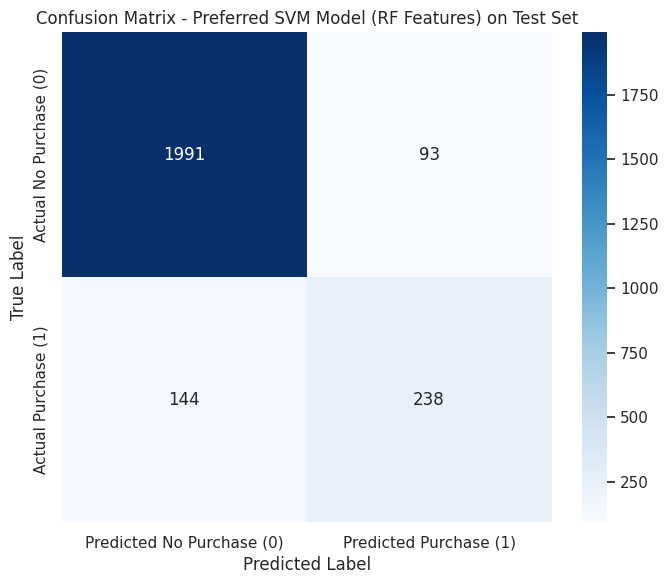

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


print("Final Model Application to Unseen Test Set (svm_model_rf)")


# 1. Make predictions on the X_svm_method1_test data
y_pred_final_rf = svm_model_rf.predict(X_svm_method1_test)

# 2. Get the probability predictions for the positive class
y_prob_final_rf = svm_model_rf.predict_proba(X_svm_method1_test)[:, 1]

print("\nPerformance on the Unseen Test Set (Class 1 - Purchase):")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_final_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_final_rf, pos_label=1):.4f}")
print(f"  ROC AUC  : {roc_auc_score(y_test, y_prob_final_rf):.4f}")

# 4. Print the classification report
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_pred_final_rf))

# 5. Compute the confusion matrix
conf_matrix_final_rf = confusion_matrix(y_test, y_pred_final_rf)

# 6. Visualize the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_final_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Purchase (0)', 'Predicted Purchase (1)'],
            yticklabels=['Actual No Purchase (0)', 'Actual Purchase (1)'])
plt.title('Confusion Matrix - Preferred SVM Model (RF Features) on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()



The evaluation on the unseen test data confirms that our preferred SVM model is a strong and reliable predictor.

**Quantitative Performance Metrics**:

*   **Overall Accuracy**: The model achieved a high accuracy of **90.39%**.
*   **Positive Class (Purchase) Performance**:
    *   **Precision: 0.7190** - When the model predicts a purchase, it is correct about 72% of the time.
    *   **Recall: 0.6230** - The model successfully identifies 62.3% of all actual purchases.
    *   **F1-Score: 0.6676** - The balanced score for the purchase class is robust.
    *   **ROC AUC: 0.8857** - The model demonstrates an excellent ability to distinguish between purchasers and non-purchasers.

**Confusion Matrix Breakdown**:

*   **True Negatives (TN): 1991** - The model excels at correctly identifying non-purchasers.
*   **True Positives (TP): 238** - It successfully identified 238 customers who made a purchase.
*   **False Positives (FP): 93** - The model made 93 incorrect purchase predictions.
*   **False Negatives (FN): 144** - It missed 144 actual purchasing customers.



# **11. Summary**

### Data Analysis Key Findings

* **Model Selection**:  
  The SVM model utilizing Random Forest features (`svm_model_rf`) was selected as the preferred model due to its marginally higher F1-score for Class 1 (Purchase prediction) compared to other evaluated models.

* **Cross-Validation Performance**:
    * The 5-fold stratified cross-validation on the training data showed consistent performance with:
        * Average F1-score (Purchase class): **0.6602 ± 0.0128**
        * Average Precision: **0.7344 ± 0.0261**
        * Average Recall: **0.6003 ± 0.0146**
        * Average ROC AUC: **0.8767 ± 0.0112**
        * Overall Accuracy: **0.9044 ± 0.0044**

* **Unseen Test Set Performance**:
    * On the unseen test set, the model achieved an overall Accuracy of **0.9039**.
    * For Class 1 (Purchase):  
      Precision = **0.7190**, Recall = **0.6230**, F1-Score = **0.6676**
    * ROC AUC on the test set was **0.8857**.

* **Confusion Matrix Analysis**:
    * Correctly predicted purchases (True Positives): **238**
    * Missed purchases (False Negatives): **144**
    * Correctly predicted non-purchases (True Negatives): **1991**
    * Incorrectly predicted purchases (False Positives): **93**

  This means the model has **high precision** (avoids false positives) but **moderate recall** (misses some actual buyers).


# **12. Conclusion**

This study aimed to **predict online shopper purchase behavior** by integrating **clustering** for behavioral segmentation and **Support Vector Machine (SVM)** for supervised classification. Through rigorous **data preprocessing** and **feature engineering**, the dataset was normalized using the **Yeo-Johnson transformation** and standardized with **Z-score scaling**, ensuring balanced feature contribution. **Random Forest** and **Principal Component Analysis (PCA)** identified key predictors such as ***PageValues***, ***ExitRates***, and ***ProductRelated_Duration***, which played a central role in both clustering and classification stages.

**Clustering analysis** using hierarchical and **K-Means methods** revealed **two distinct behavioral segments**. The first cluster represented users with **high engagement**, **low exit rates**, and **higher *PageValues***, indicating **strong purchase intent**. The second cluster comprised users with **low engagement** and **high bounce rates**, reflecting **weak purchase intent**. While the clustering approach provided meaningful insights into user behavior (**24.2% vs. 6.7%** purchase rates between clusters), the overall **41.4% agreement** with actual purchase labels highlighted its **limitations for direct prediction**, necessitating a **supervised learning approach**.

The **SVM model**, trained using **Random Forest–selected features**, achieved approximately **90% accuracy**, **72% precision**, and **62% recall** for purchase prediction, with an **F1-score of 67%** and **ROC-AUC of 0.89**. These metrics indicate **strong overall performance** and reliable discrimination between purchasing and non-purchasing users. However, the model missed **144 actual purchases**, revealing opportunities to enhance **recall** through **class balancing techniques** such as **SMOTE** or **cost-sensitive learning**, along with further **hyperparameter optimization**.

From a **business perspective**, the combination of **clustering and SVM** offers **actionable insights**. Cluster-based segmentation allows marketers to design **targeted campaigns**—promoting conversions among **high-intent users** and **re-engagement strategies** for **low-intent users**. Meanwhile, deploying the **SVM model in real time** can enable **personalized recommendations**, **live chat support**, and **adaptive marketing actions**.

In conclusion, **online purchase behavior can indeed be predicted with considerable accuracy** when **clustering-based behavioral insights** are combined with **supervised machine learning**. While clustering alone is insufficient for precise prediction, **SVM with well-engineered features** demonstrates **strong predictive potential**. Future work should focus on **improving recall**, experimenting with **ensemble** and **deep learning models**, and validating performance in a **real-world deployment environment**.

Finally, an important consideration arises for marketing application: *Should **recall** be prioritized to capture more potential buyers, or should **precision** be emphasized to optimize marketing costs?* The answer depends on business objectives—but this study provides a **strong data-driven foundation** for making that strategic choice.
